# 3-dars: Classification Modellar

## 📚 Dars maqsadi
Ushbu darsda biz classification (tasniflash) modellarini o'rganamiz:
- **Logistic Regression** - oddiy va kuchli binary/multiclass classifier
- **k-Nearest Neighbors (k-NN)** - distance-based classification
- **Decision Tree** - interpretable tree-based model
- **Random Forest** - powerful ensemble method

---

In [26]:
# Kerakli kutubxonalarni import qilish
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

# Vizualizatsiya sozlamalari
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Barcha kutubxonalar muvaffaqiyatli yuklandi!")

✅ Barcha kutubxonalar muvaffaqiyatli yuklandi!


---

# 🎯 Classification nima?

**Classification** - supervised learning algoritmi bo'lib, ma'lumotlarni **kategoriyalarga** (class'larga) ajratadi.

## Classification vs Regression

| Aspect | Classification | Regression |
|--------|----------------|------------|
| **Output** | Kategorik (0/1, Cat/Dog) | Raqamli (Narx, Harorat) |
| **Goal** | Class'ni aniqlash | Qiymatni bashorat | 
| **Example** | Spam detection | Uy narxi |
| **Metrics** | Accuracy, F1 | R², RMSE |

## Classification turlari

### 1. Binary Classification (2 class)
- Spam / Not Spam
- Disease / No Disease
- Pass / Fail

### 2. Multiclass Classification (>2 class)
- Cat / Dog / Bird
- A / B / C / D / F (baholar)
- Red / Green / Blue

### 3. Multilabel Classification
- Bir object bir nechta class'ga tegishli
- Movie genres: Action, Comedy, Drama

---

# 1️⃣ Logistic Regression

## 📖 Nazariya

**Logistic Regression** - bu classification uchun mo'ljallangan algoritm. Nomi "regression" bo'lsa-da, bu aslida **classifier**!

### 📐 Matematika

**Linear Regression** (regression):
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

**Logistic Regression** (classification):
$$P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + ... + \beta_n x_n)}}$$

Bu **Sigmoid funksiya** (yoki Logistic funksiya):
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### Sigmoid funksiyaning xususiyatlari:
- Output: 0 dan 1 gacha (probability)
- S-shakl egri chiziq
- z → ∞: σ(z) → 1
- z → -∞: σ(z) → 0
- z = 0: σ(z) = 0.5

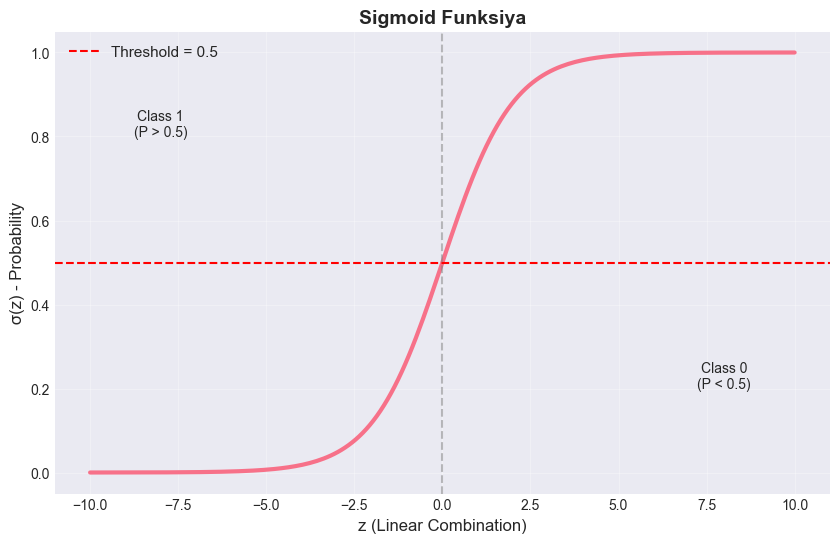

Sigmoid(0) = 0.5
Sigmoid(5) = 0.9933071490757153
Sigmoid(-5) = 0.0066928509242848554


In [27]:
# Sigmoid funksiyani vizualizatsiya qilish
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
y = sigmoid(z)

plt.figure(figsize=(10, 6))
plt.plot(z, y, linewidth=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z (Linear Combination)', fontsize=12)
plt.ylabel('σ(z) - Probability', fontsize=12)
plt.title('Sigmoid Funksiya', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.text(-8, 0.8, 'Class 1\n(P > 0.5)', fontsize=10, ha='center')
plt.text(8, 0.2, 'Class 0\n(P < 0.5)', fontsize=10, ha='center')
plt.show()

print("Sigmoid(0) =", sigmoid(0))
print("Sigmoid(5) =", sigmoid(5))
print("Sigmoid(-5) =", sigmoid(-5))

### 📊 Logistic Regression: Decision Boundary Vizualizatsiyasi

Logistic Regression **chiziqli decision boundary** hosil qiladi. Bu degani, u ma'lumotlarni **to'g'ri chiziq** (2D), **tekislik** (3D) yoki **gipertekislik** (>3D) bilan ajratadi.

Keling, oddiy 2D misolda ko'ramiz:

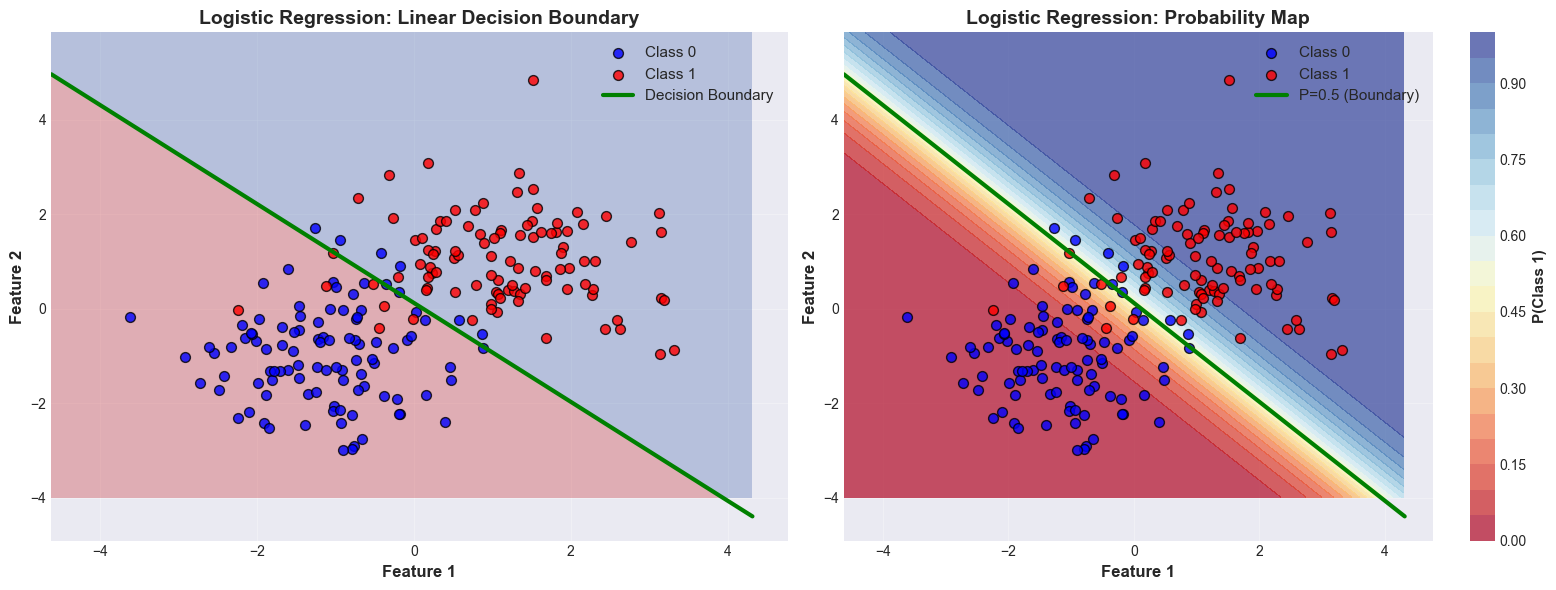


📐 Model Parametrlari:
Coefficients (w): [1.8558, 1.7713]
Intercept (b): -0.2212

📊 Decision Boundary Formula:
y = -(1.8558 * x1 + -0.2212) / 1.7713

✅ Model Accuracy: 0.9250

💡 Tushuntirish:
- Yashil chiziq: Decision boundary (P=0.5)
- Ko'k region: P(Class 1) < 0.5 → Class 0
- Qizil region: P(Class 1) > 0.5 → Class 1
- Rang'ning intensivligi: Prediction'ning ishonchi (confidence)


In [60]:
# Oddiy 2D data yaratish - Linear separable
np.random.seed(42)

# Class 0 (Blue) - Pastda
X_class0_lr = np.random.randn(100, 2) + [-1, -1]
# Class 1 (Red) - Yuqorida
X_class1_lr = np.random.randn(100, 2) + [1, 1]

X_lr = np.vstack([X_class0_lr, X_class1_lr])
y_lr = np.hstack([np.zeros(100), np.ones(100)])

# Logistic Regression model
log_reg_visual = LogisticRegression()
log_reg_visual.fit(X_lr, y_lr)

# Decision boundary chizish uchun meshgrid
h = 0.02  # mesh qadam hajmi
x_min, x_max = X_lr[:, 0].min() - 1, X_lr[:, 0].max() + 1
y_min, y_max = X_lr[:, 1].min() - 1, X_lr[:, 1].max() + 1
xx_lr, yy_lr = np.meshgrid(np.arange(x_min, x_max, h),
                            np.arange(y_min, y_max, h))

# Har bir nuqta uchun bashorat
Z_lr = log_reg_visual.predict(np.c_[xx_lr.ravel(), yy_lr.ravel()])
Z_lr = Z_lr.reshape(xx_lr.shape)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Decision Boundary
axes[0].contourf(xx_lr, yy_lr, Z_lr, alpha=0.3, cmap='RdYlBu')
axes[0].scatter(X_lr[y_lr==0, 0], X_lr[y_lr==0, 1], 
                c='blue', s=50, alpha=0.8, edgecolors='black', linewidth=1, label='Class 0')
axes[0].scatter(X_lr[y_lr==1, 0], X_lr[y_lr==1, 1], 
                c='red', s=50, alpha=0.8, edgecolors='black', linewidth=1, label='Class 1')

# Decision boundary chiziq (coefficient'lardan)
w = log_reg_visual.coef_[0]
b = log_reg_visual.intercept_[0]
x_boundary = np.linspace(x_min, x_max, 100)
y_boundary = -(w[0] * x_boundary + b) / w[1]
axes[0].plot(x_boundary, y_boundary, 'g-', linewidth=3, label='Decision Boundary')

axes[0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression: Linear Decision Boundary', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Probability Map
Z_proba = log_reg_visual.predict_proba(np.c_[xx_lr.ravel(), yy_lr.ravel()])[:, 1]
Z_proba = Z_proba.reshape(xx_lr.shape)

contour = axes[1].contourf(xx_lr, yy_lr, Z_proba, levels=20, cmap='RdYlBu', alpha=0.7)
axes[1].scatter(X_lr[y_lr==0, 0], X_lr[y_lr==0, 1], 
                c='blue', s=50, alpha=0.8, edgecolors='black', linewidth=1, label='Class 0')
axes[1].scatter(X_lr[y_lr==1, 0], X_lr[y_lr==1, 1], 
                c='red', s=50, alpha=0.8, edgecolors='black', linewidth=1, label='Class 1')
axes[1].plot(x_boundary, y_boundary, 'g-', linewidth=3, label='P=0.5 (Boundary)')

cbar = plt.colorbar(contour, ax=axes[1])
cbar.set_label('P(Class 1)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[1].set_title('Logistic Regression: Probability Map', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📐 Model Parametrlari:")
print(f"Coefficients (w): [{w[0]:.4f}, {w[1]:.4f}]")
print(f"Intercept (b): {b:.4f}")
print(f"\n📊 Decision Boundary Formula:")
print(f"y = -({w[0]:.4f} * x1 + {b:.4f}) / {w[1]:.4f}")
print(f"\n✅ Model Accuracy: {log_reg_visual.score(X_lr, y_lr):.4f}")
print("\n💡 Tushuntirish:")
print("- Yashil chiziq: Decision boundary (P=0.5)")
print("- Ko'k region: P(Class 1) < 0.5 → Class 0")
print("- Qizil region: P(Class 1) > 0.5 → Class 1")
print("- Rang'ning intensivligi: Prediction'ning ishonchi (confidence)")

## 💡 Misol 1: Binary Classification - Exam Pass/Fail

Talabaning o'qish vaqti va darsga qatnashuviga qarab, imtihondan o'tadimi yoki o'tmaydimi?

In [29]:
# Ma'lumotlar yaratish
np.random.seed(42)
n_students = 200

# O'qish vaqti (0-10 soat/hafta)
study_hours = np.random.uniform(0, 10, n_students)

# Qatnashuv (40-100%)
attendance = np.random.uniform(40, 100, n_students)

# Pass/Fail (1/0) - ko'proq o'qisa va qatnashsa, o'tish ehtimoli yuqori
# Logistic formula: P(pass) = sigmoid(β₀ + β₁*study + β₂*attendance)
z = -10 + 0.8 * study_hours + 0.12 * attendance + np.random.normal(0, 2, n_students)
probability = sigmoid(z)
passed = (probability > 0.5).astype(int)

# DataFrame yaratish
exam_df = pd.DataFrame({
    'study_hours': study_hours,
    'attendance': attendance,
    'passed': passed
})

print("📊 Exam Ma'lumotlari:")
print(exam_df.head(10))
print(f"\nJami talabalar: {len(exam_df)}")
print(f"O'tganlar: {passed.sum()} ({passed.sum()/len(exam_df)*100:.1f}%)")
print(f"O'tmaganlar: {len(passed) - passed.sum()} ({(len(passed) - passed.sum())/len(exam_df)*100:.1f}%)")

📊 Exam Ma'lumotlari:
   study_hours  attendance  passed
0     3.745401   78.521899       1
1     9.507143   45.048398       1
2     7.319939   49.697723       1
3     5.986585   93.913251       1
4     1.560186   76.385744       1
5     1.559945   40.551823       0
6     0.580836   46.088293       0
7     8.661761   79.810106       1
8     6.011150   40.303695       0
9     7.080726   49.648483       1

Jami talabalar: 200
O'tganlar: 151 (75.5%)
O'tmaganlar: 49 (24.5%)


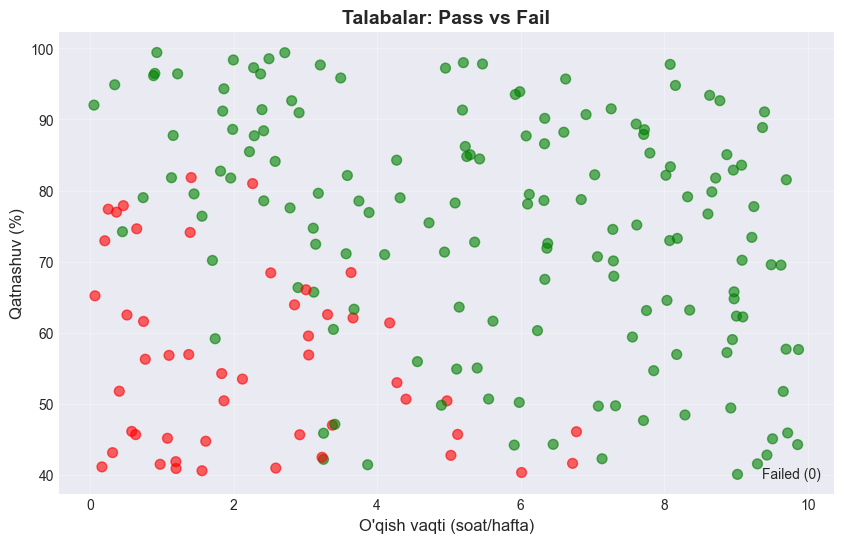

In [30]:
# Vizualizatsiya: Study hours vs Attendance
plt.figure(figsize=(10, 6))
colors = ['red' if p == 0 else 'green' for p in passed]
plt.scatter(study_hours, attendance, c=colors, alpha=0.6, s=50)
plt.xlabel('O\'qish vaqti (soat/hafta)', fontsize=12)
plt.ylabel('Qatnashuv (%)', fontsize=12)
plt.title('Talabalar: Pass vs Fail', fontsize=14, fontweight='bold')
plt.legend(['Failed (0)', 'Passed (1)'], loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Ma'lumotlarni tayyorlash
X = exam_df[['study_hours', 'attendance']] # features
y = exam_df['passed'] # target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Logistic Regression uchun muhim emas, lekin yaxshi practice)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (160, 2)
Test set: (40, 2)


In [62]:
print(X_train.head())
print(X_train_scaled[:5])

     study_hours  attendance
79      1.158691   87.747560
197     8.971103   65.739642
38      6.842330   78.728338
24      4.560700   55.912142
122     3.180035   79.611843
[[-1.2447074   1.00067585]
 [ 1.41234564 -0.23592384]
 [ 0.68833608  0.4938961 ]
 [-0.08766153 -0.78811976]
 [-0.55723487  0.54353922]]


In [32]:
# Logistic Regression modeli
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model parametrlari
print("Model parametrlari:")
print(f"Intercept: {log_reg.intercept_[0]:.4f}")
print(f"Coefficients:")
for feature, coef in zip(X.columns, log_reg.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

Model parametrlari:
Intercept: 2.3308
Coefficients:
  study_hours: 2.1031
  attendance: 1.8782


In [33]:
# Bashorat qilish
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

# Birinchi 10 ta bashoratni ko'rish
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Probability': y_pred_proba[:10]
})
print("\nBirinchi 10 ta bashorat:")
print(results)


Birinchi 10 ta bashorat:
   Actual  Predicted  Probability
0       1          1     0.928484
1       0          0     0.188297
2       1          1     0.993959
3       1          1     0.967013
4       0          0     0.172419
5       1          1     0.998282
6       1          1     0.990461
7       0          1     0.770184
8       1          1     0.687896
9       1          1     0.998242


### Model Baholash: Confusion Matrix

**Confusion Matrix** - classification modellarini baholashning asosiy vositasi.

```
                Predicted
              0         1
Actual  0    TN        FP
        1    FN        TP
```

- **TN (True Negative)**: To'g'ri 0 deb bashorat qilindi
- **FP (False Positive)**: Noto'g'ri 1 deb bashorat qilindi (Type I error)
- **FN (False Negative)**: Noto'g'ri 0 deb bashorat qilindi (Type II error)
- **TP (True Positive)**: To'g'ri 1 deb bashorat qilindi

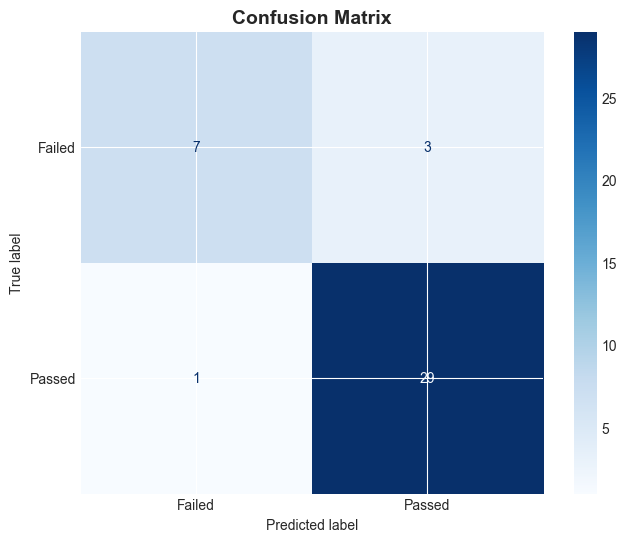


Confusion Matrix:
[[ 7  3]
 [ 1 29]]

True Negatives (TN): 7
False Positives (FP): 3
False Negatives (FN): 1
True Positives (TP): 29


In [34]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failed', 'Passed'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")

### Classification Metrics

**Accuracy**: Umumiy to'g'ri bashoratlar nisbati
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**Precision**: Positive deb bashorat qilinganlarning qanchasi haqiqatan positive
$$Precision = \frac{TP}{TP + FP}$$

**Recall (Sensitivity)**: Haqiqiy positive'larning qanchasi topildi
$$Recall = \frac{TP}{TP + FN}$$

**F1-Score**: Precision va Recall ning harmonik o'rtachasi
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

In [35]:
# Metrikalarni hisoblash
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("📊 Model Performance:")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Failed', 'Passed']))

📊 Model Performance:
Accuracy:  0.9000 (90.00%)
Precision: 0.9062 (90.62%)
Recall:    0.9667 (96.67%)
F1-Score:  0.9355

📋 Classification Report:
              precision    recall  f1-score   support

      Failed       0.88      0.70      0.78        10
      Passed       0.91      0.97      0.94        30

    accuracy                           0.90        40
   macro avg       0.89      0.83      0.86        40
weighted avg       0.90      0.90      0.90        40



### ROC Curve va AUC

**ROC (Receiver Operating Characteristic) Curve** - Turli threshold qiymatlari uchun True Positive Rate vs False Positive Rate

**AUC (Area Under Curve)** - ROC curve ostidagi maydon
- AUC = 1.0: Perfect classifier
- AUC = 0.5: Random classifier
- AUC < 0.5: Worse than random

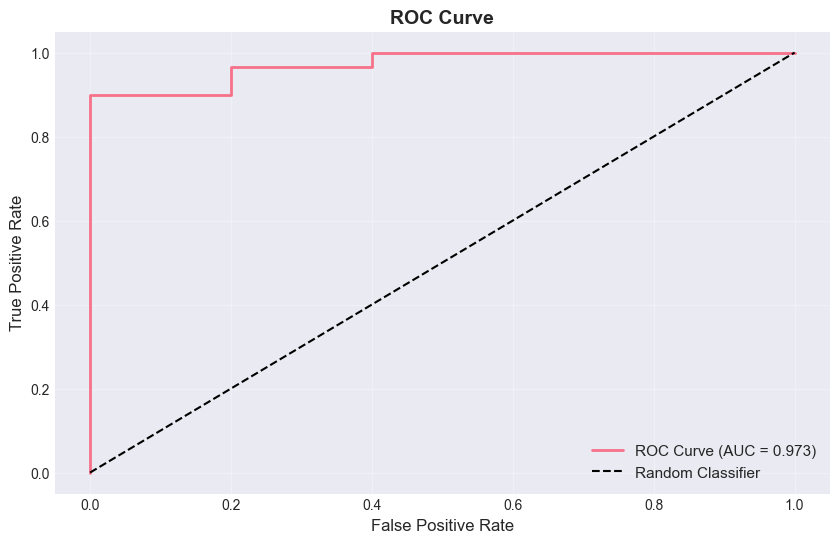

AUC Score: 0.9733


In [36]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {auc:.4f}")

## 💡 Misol 2: Multiclass Classification - Iris Dataset

Ko'p class'li classification (3 tur iris gulli).

In [37]:
# Iris dataset yuklash
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print("🌸 Iris Dataset:")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")
print(f"Namunalar: {len(X_iris)}")
print(f"\nClass distribution:")
print(pd.Series(y_iris).value_counts().sort_index())

🌸 Iris Dataset:
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
Namunalar: 150

Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64


In [64]:
# Ma'lumotlarni tayyorlash
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
) # 80 / 20 metodida bo'lyapmiz.

print(f"Train set: {X_train_i.shape}")
print(f"Test set: {X_test_i.shape}")

scaler_i = StandardScaler()
X_train_i_scaled = scaler_i.fit_transform(X_train_i)
X_test_i_scaled = scaler_i.transform(X_test_i)

# Multiclass Logistic Regression
log_reg_multi = LogisticRegression(max_iter=200, random_state=42)
log_reg_multi.fit(X_train_i_scaled, y_train_i)

# Bashorat
y_pred_i = log_reg_multi.predict(X_test_i_scaled)

# Baholash
accuracy_i = accuracy_score(y_test_i, y_pred_i)
print(f"Accuracy: {accuracy_i:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))

Train set: (120, 4)
Test set: (30, 4)
Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



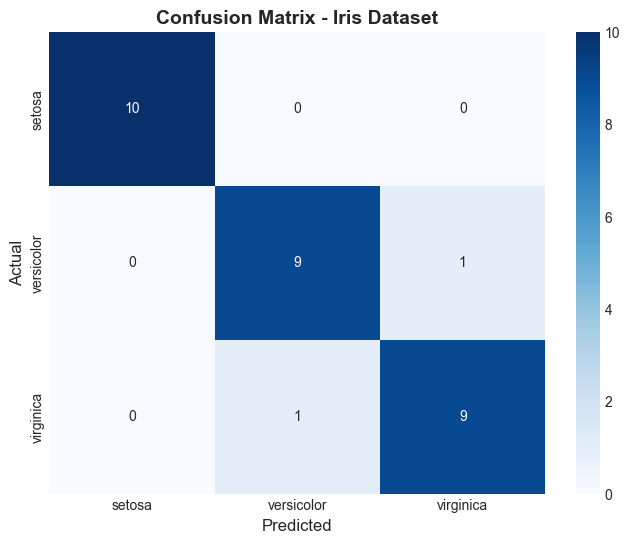

In [39]:
# Multiclass Confusion Matrix
cm_multi = confusion_matrix(y_test_i, y_pred_i)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Iris Dataset', fontsize=14, fontweight='bold')
plt.show()

---

# 2️⃣ k-Nearest Neighbors (k-NN)

## 📖 Nazariya

**k-NN** - eng oddiy classification algoritmi. Yangi nuqtani eng yaqin k ta qo'shnisiga qarab tasniflaydi.

### Algoritm:
1. k ni tanlash (masalan, k=5)
2. Yangi nuqta uchun barcha training nuqtalargacha masofani hisoblash
3. Eng yaqin k ta nuqtani topish
4. Eng ko'p uchraydigan class'ni tanlash (voting)

### Distance Metrics:

**Euclidean Distance** (eng keng tarqalgan):
$$d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$$

**Manhattan Distance**:
$$d(x, y) = \sum_{i=1}^{n}|x_i - y_i|$$

**Minkowski Distance** (umumiy):
$$d(x, y) = \left(\sum_{i=1}^{n}|x_i - y_i|^p\right)^{1/p}$$

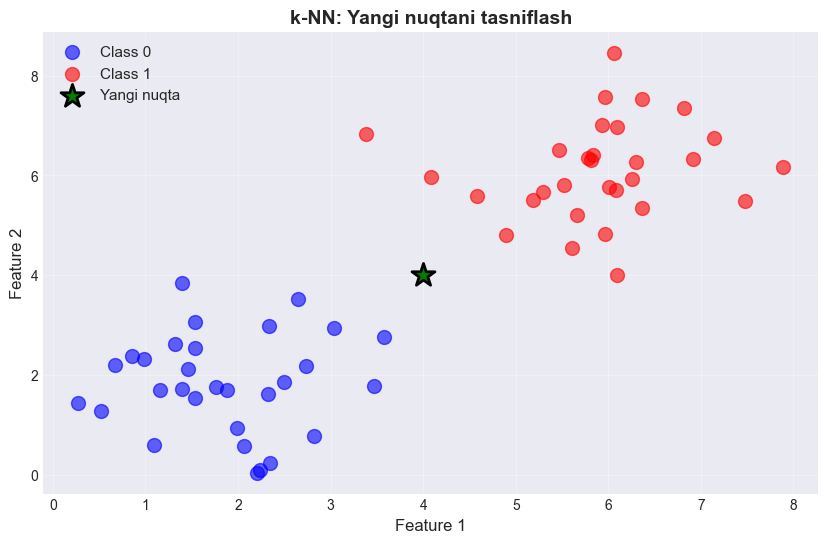

In [40]:
# k-NN visualizatsiya uchun oddiy 2D data
np.random.seed(42)

# Class 0
X_class0 = np.random.randn(30, 2) + [2, 2]
# Class 1
X_class1 = np.random.randn(30, 2) + [6, 6]

X_knn = np.vstack([X_class0, X_class1])
y_knn = np.hstack([np.zeros(30), np.ones(30)])

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_class0[:, 0], X_class0[:, 1], c='blue', s=100, alpha=0.6, label='Class 0')
plt.scatter(X_class1[:, 0], X_class1[:, 1], c='red', s=100, alpha=0.6, label='Class 1')

# Yangi nuqta
new_point = [4, 4]
plt.scatter(new_point[0], new_point[1], c='green', s=300, marker='*', 
            edgecolors='black', linewidths=2, label='Yangi nuqta', zorder=5)

plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.title('k-NN: Yangi nuqtani tasniflash', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

### 🔍 k-NN: Qanday ishlashini batafsil ko'rish

k-NN algoritmi juda oddiy:
1. **Yangi nuqtadan barcha training nuqtalargacha masofa hisoblash**
2. **Eng yaqin k ta nuqtani topish**
3. **Ko'pchilik ovozi (majority voting) orqali class aniqlash**

Keling, buni qadam-baqadam ko'ramiz:

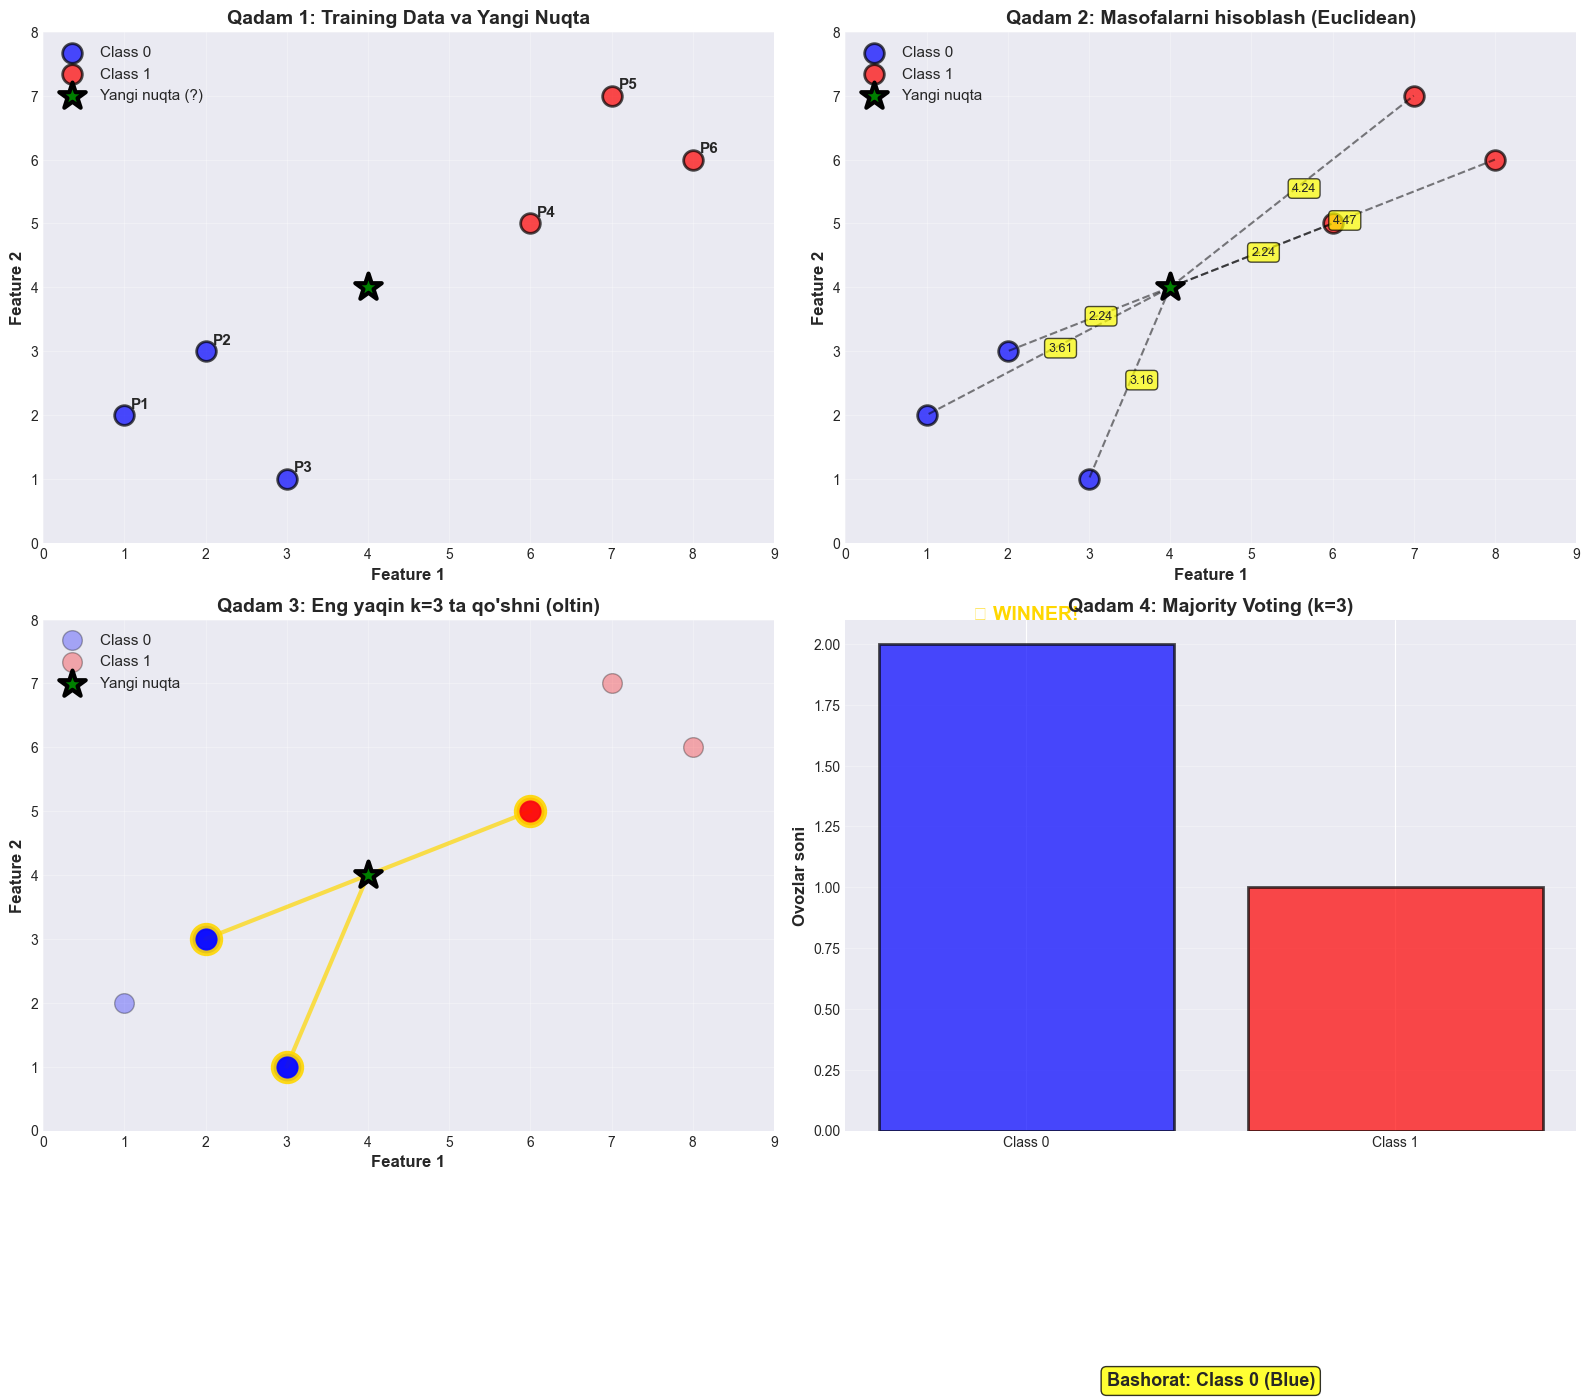


k-NN ALGORITMI - QADAM-BAQADAM TUSHUNTIRISH

📍 Yangi nuqta: [4 4]

📏 Masofalar (Euclidean):
  P1 [1 2] → Class 0: 3.6056
  P2 [2 3] → Class 0: 2.2361
  P3 [3 1] → Class 0: 3.1623
  P4 [6 5] → Class 1: 2.2361
  P5 [7 7] → Class 1: 4.2426
  P6 [8 6] → Class 1: 4.4721

🎯 k = 3 uchun eng yaqin qo'shnilar:
  P2 → Class 0 (masofa: 2.2361)
  P4 → Class 1 (masofa: 2.2361)
  P3 → Class 0 (masofa: 3.1623)

🗳️ Voting natijasi:
  Class 0: 2 ovoz
  Class 1: 1 ovoz

✅ Yakuniy bashorat: Class 0 (Blue)


In [59]:
# k-NN qanday ishlashini ko'rsatish
np.random.seed(42)

# Training data
X_knn_demo = np.array([[1, 2], [2, 3], [3, 1], [6, 5], [7, 7], [8, 6]])
y_knn_demo = np.array([0, 0, 0, 1, 1, 1])  # 0=Blue, 1=Red

# Yangi nuqta (yashil)
new_point_demo = np.array([4, 4])

# Masofalarni hisoblash
from scipy.spatial.distance import euclidean, cityblock

distances_euclidean = [euclidean(new_point_demo, point) for point in X_knn_demo]
distances_manhattan = [cityblock(new_point_demo, point) for point in X_knn_demo]

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. Barcha nuqtalar va yangi nuqta
axes[0, 0].scatter(X_knn_demo[y_knn_demo==0, 0], X_knn_demo[y_knn_demo==0, 1], 
                   c='blue', s=200, alpha=0.7, edgecolors='black', linewidth=2, label='Class 0')
axes[0, 0].scatter(X_knn_demo[y_knn_demo==1, 0], X_knn_demo[y_knn_demo==1, 1], 
                   c='red', s=200, alpha=0.7, edgecolors='black', linewidth=2, label='Class 1')
axes[0, 0].scatter(new_point_demo[0], new_point_demo[1], 
                   c='green', s=400, marker='*', edgecolors='black', linewidth=3, 
                   label='Yangi nuqta (?)', zorder=5)

# Nuqtalarga label qo'yish
for i, (x, y) in enumerate(X_knn_demo):
    axes[0, 0].annotate(f'P{i+1}', (x, y), fontsize=11, fontweight='bold', 
                        xytext=(5, 5), textcoords='offset points')

axes[0, 0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Qadam 1: Training Data va Yangi Nuqta', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11, loc='upper left')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, 9)
axes[0, 0].set_ylim(0, 8)

# 2. Masofalarni ko'rsatish (Euclidean)
axes[0, 1].scatter(X_knn_demo[y_knn_demo==0, 0], X_knn_demo[y_knn_demo==0, 1], 
                   c='blue', s=200, alpha=0.7, edgecolors='black', linewidth=2, label='Class 0')
axes[0, 1].scatter(X_knn_demo[y_knn_demo==1, 0], X_knn_demo[y_knn_demo==1, 1], 
                   c='red', s=200, alpha=0.7, edgecolors='black', linewidth=2, label='Class 1')
axes[0, 1].scatter(new_point_demo[0], new_point_demo[1], 
                   c='green', s=400, marker='*', edgecolors='black', linewidth=3, 
                   label='Yangi nuqta', zorder=5)

# Masofalarni chizish
for i, (point, dist) in enumerate(zip(X_knn_demo, distances_euclidean)):
    axes[0, 1].plot([new_point_demo[0], point[0]], [new_point_demo[1], point[1]], 
                    'k--', alpha=0.5, linewidth=1.5)
    mid_x = (new_point_demo[0] + point[0]) / 2
    mid_y = (new_point_demo[1] + point[1]) / 2
    axes[0, 1].text(mid_x, mid_y, f'{dist:.2f}', fontsize=9, 
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

axes[0, 1].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Qadam 2: Masofalarni hisoblash (Euclidean)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11, loc='upper left')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 9)
axes[0, 1].set_ylim(0, 8)

# 3. k=3 uchun eng yaqin qo'shnilar
k = 3
nearest_indices = np.argsort(distances_euclidean)[:k]
nearest_classes = y_knn_demo[nearest_indices]

axes[1, 0].scatter(X_knn_demo[y_knn_demo==0, 0], X_knn_demo[y_knn_demo==0, 1], 
                   c='blue', s=200, alpha=0.3, edgecolors='black', linewidth=1, label='Class 0')
axes[1, 0].scatter(X_knn_demo[y_knn_demo==1, 0], X_knn_demo[y_knn_demo==1, 1], 
                   c='red', s=200, alpha=0.3, edgecolors='black', linewidth=1, label='Class 1')
axes[1, 0].scatter(new_point_demo[0], new_point_demo[1], 
                   c='green', s=400, marker='*', edgecolors='black', linewidth=3, 
                   label='Yangi nuqta', zorder=5)

# Eng yaqin k ta nuqtani highlight qilish
for idx in nearest_indices:
    color = 'blue' if y_knn_demo[idx] == 0 else 'red'
    axes[1, 0].scatter(X_knn_demo[idx, 0], X_knn_demo[idx, 1], 
                       c=color, s=400, alpha=0.9, edgecolors='gold', linewidth=4, zorder=4)
    axes[1, 0].plot([new_point_demo[0], X_knn_demo[idx, 0]], 
                    [new_point_demo[1], X_knn_demo[idx, 1]], 
                    'gold', linewidth=3, alpha=0.7)

axes[1, 0].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'Qadam 3: Eng yaqin k={k} ta qo\'shni (oltin)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11, loc='upper left')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 9)
axes[1, 0].set_ylim(0, 8)

# 4. Voting - Yakuniy qaror
from collections import Counter
vote_counts = Counter(nearest_classes)
predicted_class = vote_counts.most_common(1)[0][0]
predicted_label = 'Class 0 (Blue)' if predicted_class == 0 else 'Class 1 (Red)'

# Bar chart - voting
axes[1, 1].bar(['Class 0', 'Class 1'], 
               [vote_counts[0], vote_counts[1]], 
               color=['blue', 'red'], alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Ovozlar soni', fontsize=12, fontweight='bold')
axes[1, 1].set_title(f'Qadam 4: Majority Voting (k={k})', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Winner'ni ko'rsatish
winner_x = 0 if predicted_class == 0 else 1
axes[1, 1].text(winner_x, vote_counts[predicted_class] + 0.1, '🏆 WINNER!', 
                ha='center', fontsize=14, fontweight='bold', color='gold')

axes[1, 1].text(0.5, -0.5, f'Bashorat: {predicted_label}', 
                ha='center', fontsize=13, fontweight='bold', 
                transform=axes[1, 1].transAxes,
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Natijalarni chop etish
print("\n" + "="*70)
print("k-NN ALGORITMI - QADAM-BAQADAM TUSHUNTIRISH")
print("="*70)
print(f"\n📍 Yangi nuqta: {new_point_demo}")
print(f"\n📏 Masofalar (Euclidean):")
for i, (point, dist) in enumerate(zip(X_knn_demo, distances_euclidean)):
    print(f"  P{i+1} {point} → Class {y_knn_demo[i]}: {dist:.4f}")

print(f"\n🎯 k = {k} uchun eng yaqin qo'shnilar:")
for idx in nearest_indices:
    print(f"  P{idx+1} → Class {y_knn_demo[idx]} (masofa: {distances_euclidean[idx]:.4f})")

print(f"\n🗳️ Voting natijasi:")
print(f"  Class 0: {vote_counts[0]} ovoz")
print(f"  Class 1: {vote_counts[1]} ovoz")

print(f"\n✅ Yakuniy bashorat: {predicted_label}")
print("="*70)

### 📏 Distance Metrics: Euclidean vs Manhattan vs Minkowski

Turli distance metric'lar turli natijalar beradi. Keling, ularni taqqoslaylik:

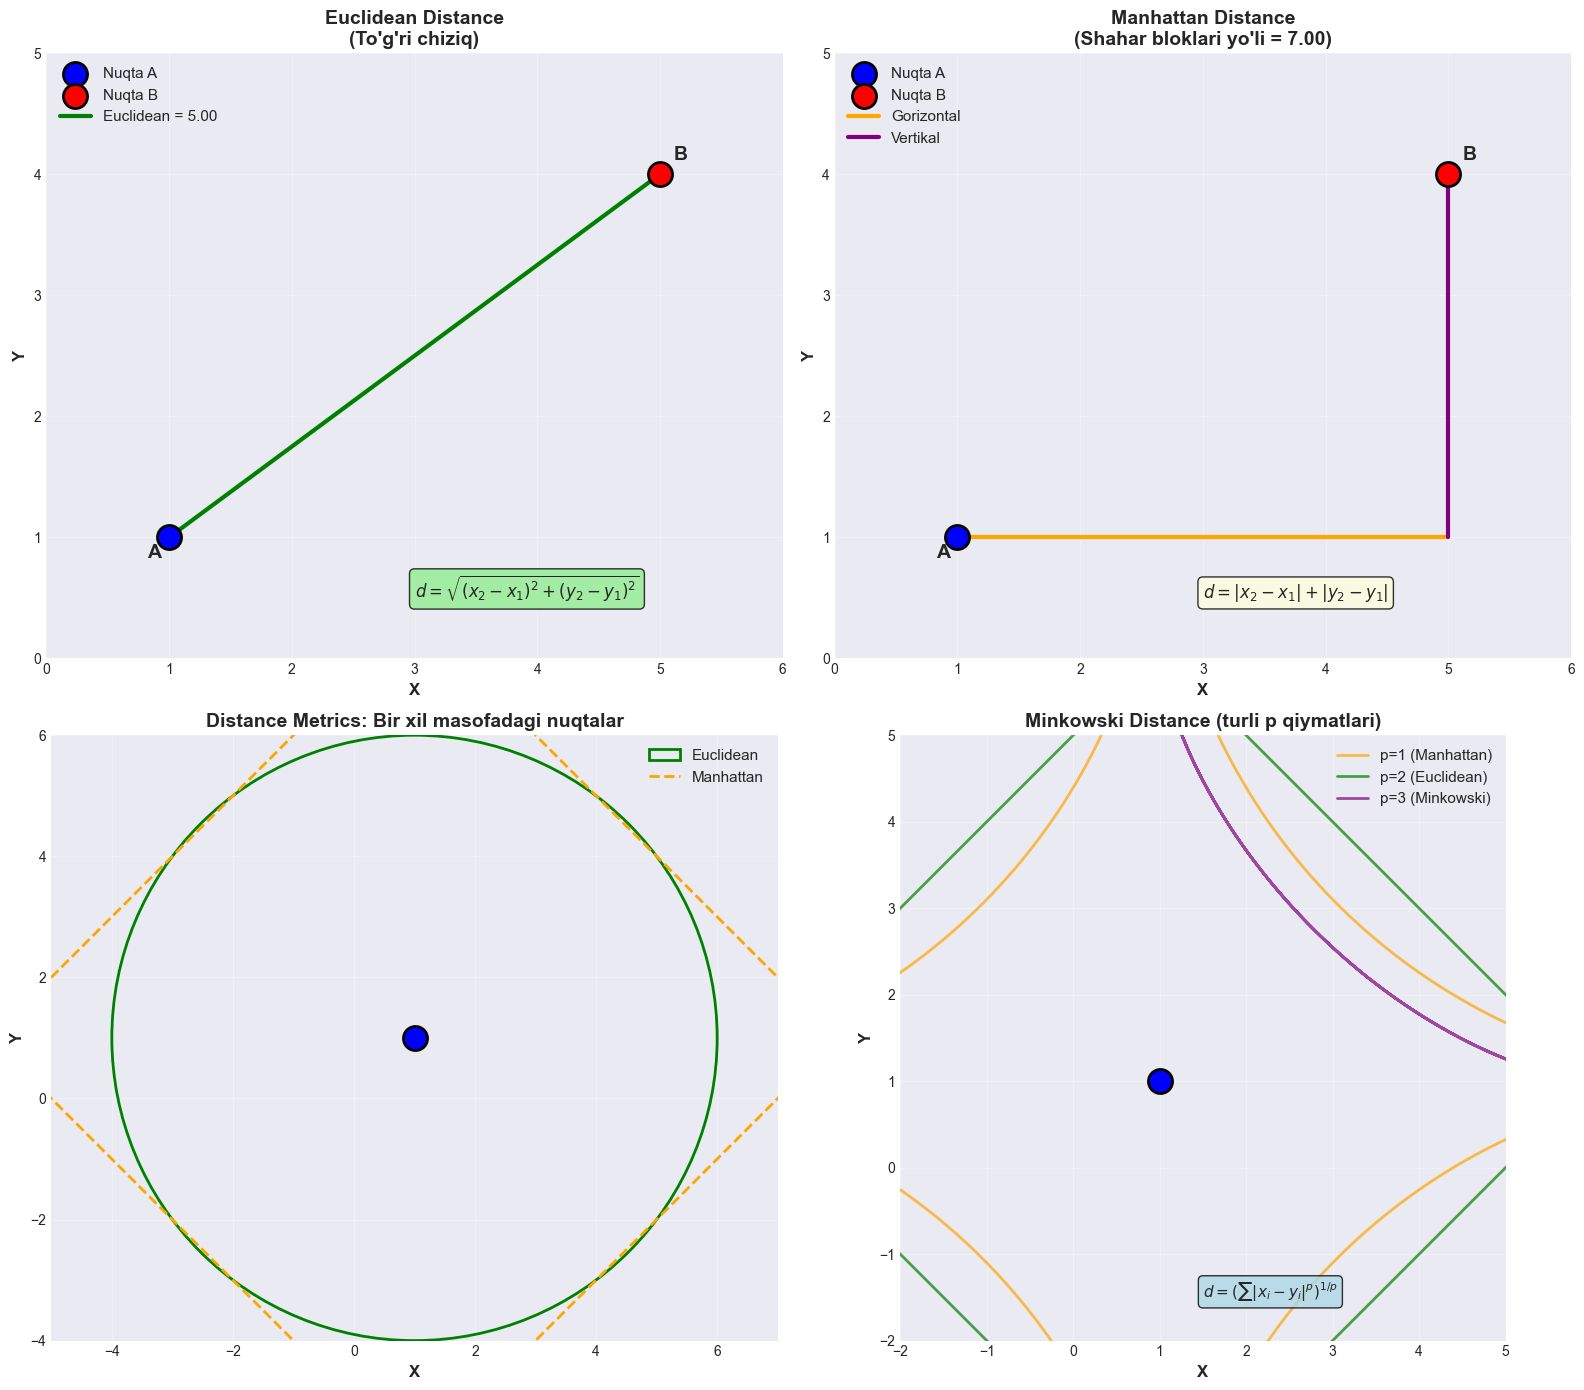


DISTANCE METRICS TAQQOSLASH

Nuqta A: [1 1]
Nuqta B: [5 4]

Metric               Formula                             Masofa    
----------------------------------------------------------------------
Euclidean            √((x₂-x₁)² + (y₂-y₁)²)              5.0000    
Manhattan            |x₂-x₁| + |y₂-y₁|                   7.0000    
Minkowski (p=3)      (Σ|xᵢ-yᵢ|³)^(1/3)                   4.4979    

💡 Qaysi metric ishlatish kerak?
- Euclidean: Eng keng tarqalgan, 'haqiqiy' masofa
- Manhattan: Grid/shahar strukturasida (masalan, taksi yo'li)
- Minkowski: Flexible, p ni sozlash mumkin


In [65]:
# Distance Metrics Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Nuqtalar
point_A = np.array([1, 1])
point_B = np.array([5, 4])

# Euclidean Distance
euclidean_dist = np.sqrt((point_B[0]-point_A[0])**2 + (point_B[1]-point_A[1])**2)

axes[0, 0].scatter(*point_A, s=300, c='blue', marker='o', edgecolors='black', linewidth=2, label='Nuqta A', zorder=5)
axes[0, 0].scatter(*point_B, s=300, c='red', marker='o', edgecolors='black', linewidth=2, label='Nuqta B', zorder=5)
axes[0, 0].plot([point_A[0], point_B[0]], [point_A[1], point_B[1]], 
                'g-', linewidth=3, label=f'Euclidean = {euclidean_dist:.2f}')
axes[0, 0].annotate('A', point_A, fontsize=14, fontweight='bold', xytext=(-15, -15), textcoords='offset points')
axes[0, 0].annotate('B', point_B, fontsize=14, fontweight='bold', xytext=(10, 10), textcoords='offset points')
axes[0, 0].set_xlabel('X', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Y', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Euclidean Distance\n(To\'g\'ri chiziq)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11, loc='upper left')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, 6)
axes[0, 0].set_ylim(0, 5)
axes[0, 0].text(3, 0.5, r'$d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$', 
                fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Manhattan Distance
manhattan_dist = abs(point_B[0]-point_A[0]) + abs(point_B[1]-point_A[1])

axes[0, 1].scatter(*point_A, s=300, c='blue', marker='o', edgecolors='black', linewidth=2, label='Nuqta A', zorder=5)
axes[0, 1].scatter(*point_B, s=300, c='red', marker='o', edgecolors='black', linewidth=2, label='Nuqta B', zorder=5)
# Vertikal va gorizontal yo'l
axes[0, 1].plot([point_A[0], point_B[0]], [point_A[1], point_A[1]], 
                'orange', linewidth=3, linestyle='-', label='Gorizontal')
axes[0, 1].plot([point_B[0], point_B[0]], [point_A[1], point_B[1]], 
                'purple', linewidth=3, linestyle='-', label='Vertikal')
axes[0, 1].annotate('A', point_A, fontsize=14, fontweight='bold', xytext=(-15, -15), textcoords='offset points')
axes[0, 1].annotate('B', point_B, fontsize=14, fontweight='bold', xytext=(10, 10), textcoords='offset points')
axes[0, 1].set_xlabel('X', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Y', fontsize=12, fontweight='bold')
axes[0, 1].set_title(f'Manhattan Distance\n(Shahar bloklari yo\'li = {manhattan_dist:.2f})', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11, loc='upper left')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 6)
axes[0, 1].set_ylim(0, 5)
axes[0, 1].text(3, 0.5, r'$d = |x_2-x_1| + |y_2-y_1|$', 
                fontsize=12, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Comparison: Circles
axes[1, 0].scatter(*point_A, s=300, c='blue', marker='o', edgecolors='black', linewidth=2, zorder=5)

# Euclidean circle
circle_euclidean = plt.Circle(point_A, euclidean_dist, color='green', fill=False, linewidth=2, linestyle='-', label='Euclidean')
axes[1, 0].add_patch(circle_euclidean)

# Manhattan "circle" (diamond)
diamond_x = [point_A[0], point_A[0] + manhattan_dist, point_A[0], point_A[0] - manhattan_dist, point_A[0]]
diamond_y = [point_A[1] + manhattan_dist, point_A[1], point_A[1] - manhattan_dist, point_A[1], point_A[1] + manhattan_dist]
axes[1, 0].plot(diamond_x, diamond_y, 'orange', linewidth=2, linestyle='--', label='Manhattan')

axes[1, 0].set_xlabel('X', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Y', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distance Metrics: Bir xil masofadagi nuqtalar', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(-5, 7)
axes[1, 0].set_ylim(-4, 6)
axes[1, 0].set_aspect('equal')

# Minkowski (p=1, 2, 3)
axes[1, 1].scatter(*point_A, s=300, c='blue', marker='o', edgecolors='black', linewidth=2, zorder=5)

for p, color, label in [(1, 'orange', 'p=1 (Manhattan)'), 
                         (2, 'green', 'p=2 (Euclidean)'), 
                         (3, 'purple', 'p=3 (Minkowski)')]:
    # Minkowski circle
    theta = np.linspace(0, 2*np.pi, 1000)
    if p == 1:
        x = point_A[0] + manhattan_dist * np.sign(np.cos(theta)) * (1 - abs(np.sin(theta)))
        y = point_A[1] + manhattan_dist * np.sign(np.sin(theta)) * (1 - abs(np.cos(theta)))
    else:
        x = point_A[0] + euclidean_dist * np.cos(theta)**p * np.sign(np.cos(theta))
        y = point_A[1] + euclidean_dist * np.sin(theta)**p * np.sign(np.sin(theta))
    axes[1, 1].plot(x, y, color=color, linewidth=2, label=label, alpha=0.7)

axes[1, 1].set_xlabel('X', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Y', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Minkowski Distance (turli p qiymatlari)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(-2, 5)
axes[1, 1].set_ylim(-2, 5)
axes[1, 1].set_aspect('equal')
axes[1, 1].text(1.5, -1.5, r'$d = (\sum|x_i - y_i|^p)^{1/p}$', 
                fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

# Summary Table
print("\n" + "="*70)
print("DISTANCE METRICS TAQQOSLASH")
print("="*70)
print(f"\nNuqta A: {point_A}")
print(f"Nuqta B: {point_B}")
print(f"\n{'Metric':<20} {'Formula':<35} {'Masofa':<10}")
print("-"*70)
print(f"{'Euclidean':<20} {'√((x₂-x₁)² + (y₂-y₁)²)':<35} {euclidean_dist:<10.4f}")
print(f"{'Manhattan':<20} {'|x₂-x₁| + |y₂-y₁|':<35} {manhattan_dist:<10.4f}")

minkowski_p3 = ((abs(point_B[0]-point_A[0])**3 + abs(point_B[1]-point_A[1])**3)**(1/3))
print(f"{'Minkowski (p=3)':<20} {'(Σ|xᵢ-yᵢ|³)^(1/3)':<35} {minkowski_p3:<10.4f}")
print("="*70)

print("\n💡 Qaysi metric ishlatish kerak?")
print("- Euclidean: Eng keng tarqalgan, 'haqiqiy' masofa")
print("- Manhattan: Grid/shahar strukturasida (masalan, taksi yo'li)")
print("- Minkowski: Flexible, p ni sozlash mumkin")

In [43]:
# k-NN modeli (Iris dataset)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_i_scaled, y_train_i)

# Bashorat
y_pred_knn = knn.predict(X_test_i_scaled)

# Baholash
accuracy_knn = accuracy_score(y_test_i, y_pred_knn)
print(f"k-NN Accuracy (k=5): {accuracy_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_knn, target_names=iris.target_names))

k-NN Accuracy (k=5): 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



### 🎨 k-NN: Decision Boundary Vizualizatsiya

Logistic Regression'dan farqli ravishda, k-NN **non-linear** decision boundary yaratadi. Bu juda murakkab shakllarga ega bo'lishi mumkin.

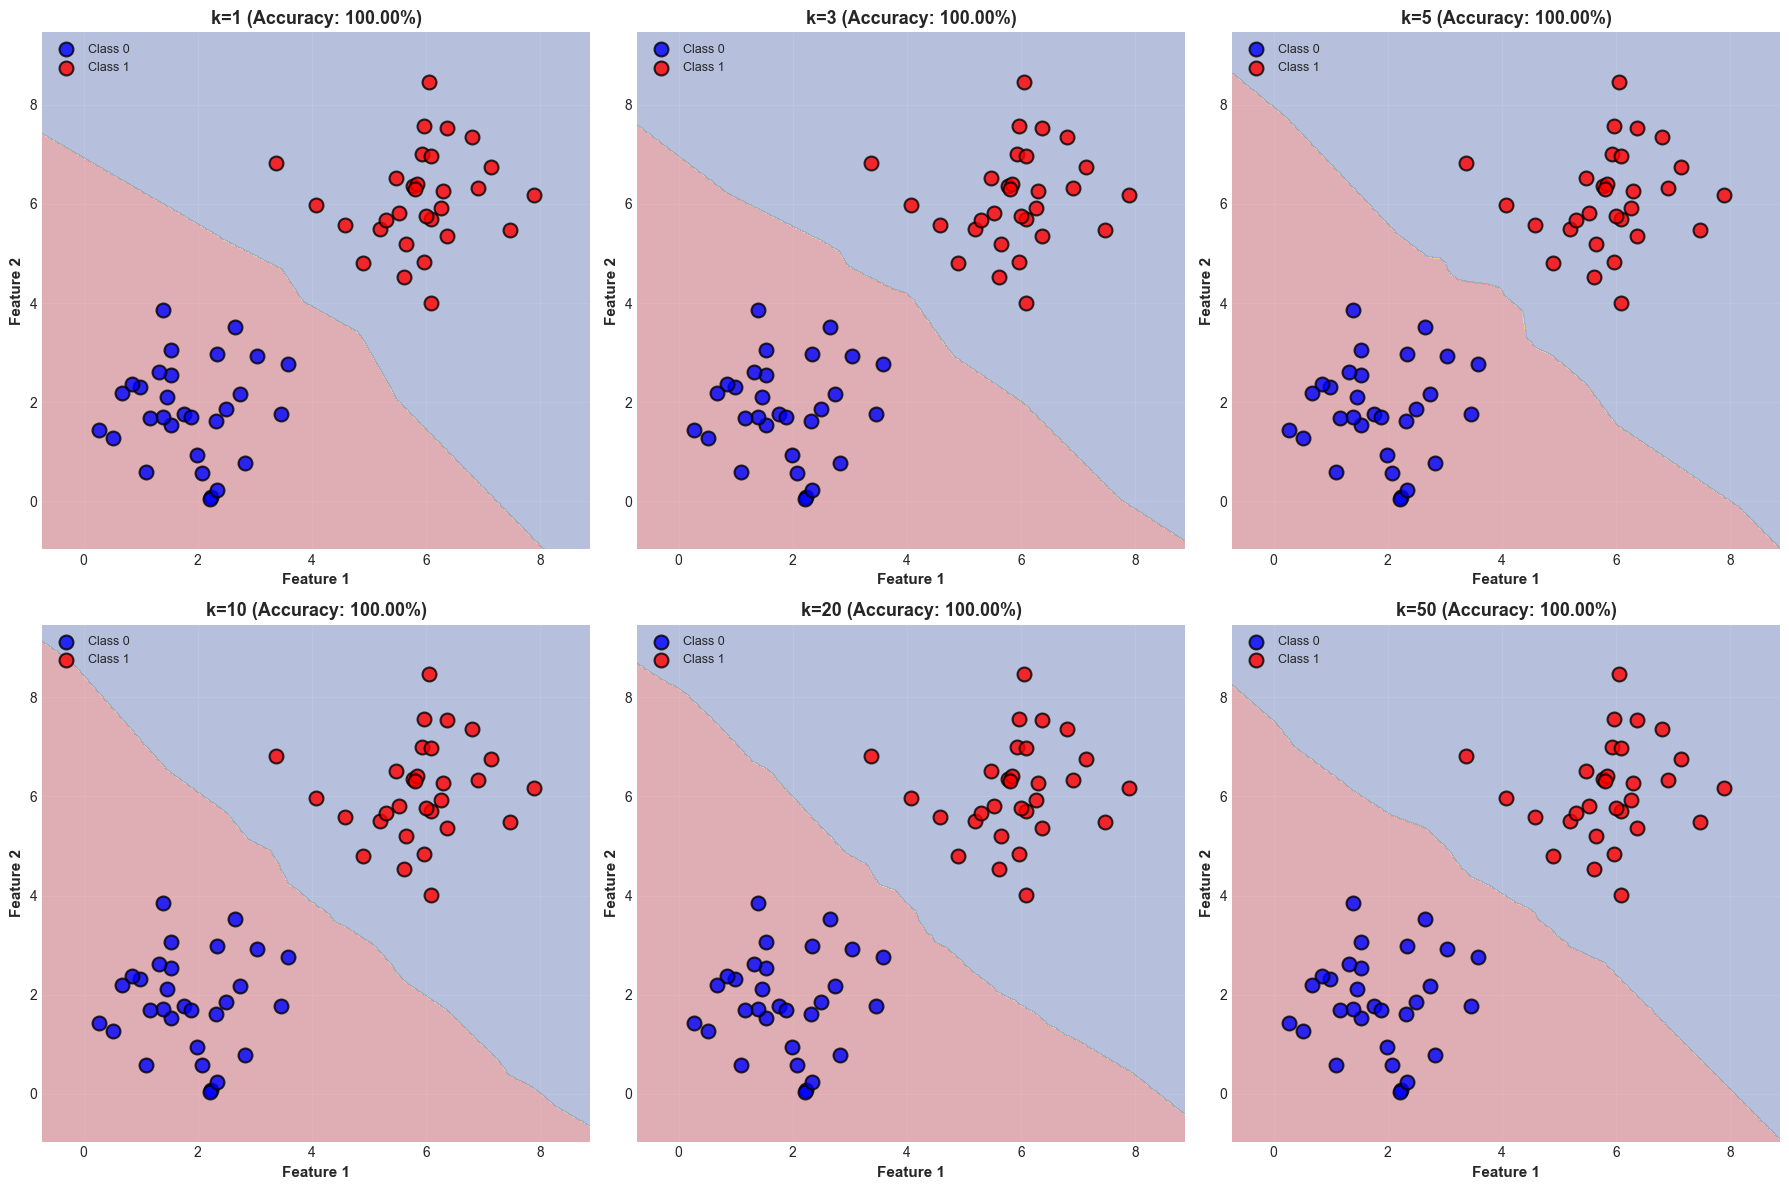

\n======================================================================
k-NN: k PARAMETRINING TA'SIRI
\n📌 Kuzatishlar:
\nk=1 (juda kichik):
  ✅ Juda murakkab boundary (har bir nuqtaga fit qiladi)
  ❌ Overfitting! Noise'ga sezgir
  ❌ Training accuracy = 100%, lekin generalization yomon
\nk=3-5 (o'rtacha):
  ✅ Balanced - na overfitting, na underfitting
  ✅ Oddiy pattern'larni yaxshi ushlab turadi
  ✅ Ko'pincha eng yaxshi choice
\nk=20-50 (katta):
  ❌ Juda smooth boundary
  ❌ Underfitting - pattern'larni o'tkazib yuboradi
  ❌ Decision boundary juda sodda
\n💡 Optimal k ni topish: Cross-validation ishlatiladi!


In [ ]:
# k-NN Decision Boundaries uchun turli k qiymatlari
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Data (o'sha 2D data)
k_values_demo = [1, 3, 5, 10, 20, 50]

for idx, k_val in enumerate(k_values_demo):
    # Model
    knn_boundary = KNeighborsClassifier(n_neighbors=k_val)
    knn_boundary.fit(X_knn, y_knn)
    
    # Decision boundary
    h = 0.02
    x_min_knn, x_max_knn = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
    y_min_knn, y_max_knn = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
    xx_knn, yy_knn = np.meshgrid(np.arange(x_min_knn, x_max_knn, h),
                                  np.arange(y_min_knn, y_max_knn, h))
    
    Z_knn = knn_boundary.predict(np.c_[xx_knn.ravel(), yy_knn.ravel()])
    Z_knn = Z_knn.reshape(xx_knn.shape)
    
    # Plot
    axes[idx].contourf(xx_knn, yy_knn, Z_knn, alpha=0.3, cmap='RdYlBu')
    axes[idx].scatter(X_knn[y_knn==0, 0], X_knn[y_knn==0, 1], 
                      c='blue', s=100, alpha=0.8, edgecolors='black', linewidth=1.5, label='Class 0')
    axes[idx].scatter(X_knn[y_knn==1, 0], X_knn[y_knn==1, 1], 
                      c='red', s=100, alpha=0.8, edgecolors='black', linewidth=1.5, label='Class 1')
    
    accuracy_knn_boundary = knn_boundary.score(X_knn, y_knn)
    axes[idx].set_xlabel('Feature 1', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Feature 2', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'k={k_val} (Accuracy: {accuracy_knn_boundary:.2%})', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=9, loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("k-NN: k PARAMETRINING TA'SIRI")
print("="*70)
print("\n📌 Kuzatishlar:")
print("\nk=1 (juda kichik):")
print("  ✅ Juda murakkab boundary (har bir nuqtaga fit qiladi)")
print("  ❌ Overfitting! Noise'ga sezgir")
print("  ❌ Training accuracy = 100%, lekin generalization yomon")

print("\nk=3-5 (o'rtacha):")
print("  ✅ Balanced - na overfitting, na underfitting")
print("  ✅ Oddiy pattern'larni yaxshi ushlab turadi")
print("  ✅ Ko'pincha eng yaxshi choice")

print("\nk=20-50 (katta):")
print("  ❌ Juda smooth boundary")
print("  ❌ Underfitting - pattern'larni o'tkazib yuboradi")
print("  ❌ Decision boundary juda sodda")

print("\n💡 Optimal k ni topish: Cross-validation ishlatiladi!")
print("="*70)

### k parametrini tanlash

**k** - eng muhim hyperparameter!

- **k kichik** (masalan k=1): Overfitting, noise'ga sezgir
- **k katta**: Underfitting, boundaries smooth
- **Optimal k**: Cross-validation bilan topiladi

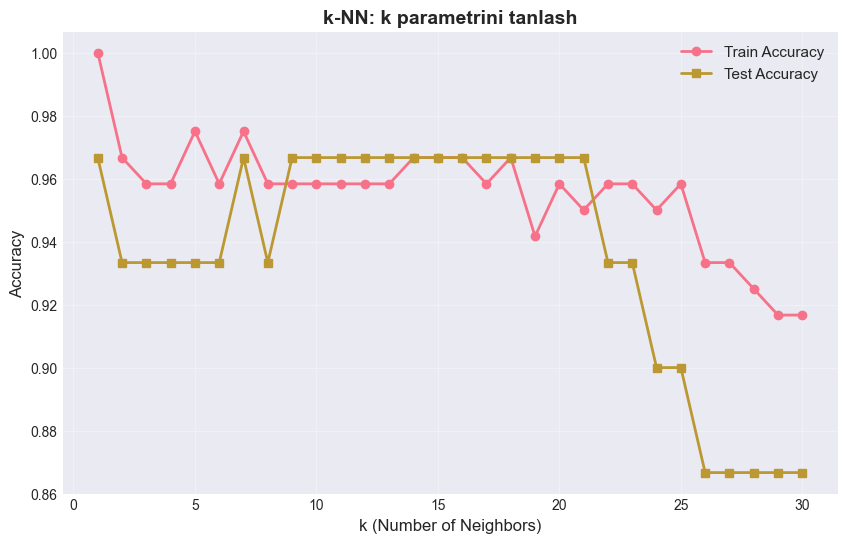


Eng yaxshi k: 1
Test Accuracy: 0.9667


In [16]:
# Turli k qiymatlari uchun accuracy
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_i_scaled, y_train_i)
    
    train_scores.append(knn.score(X_train_i_scaled, y_train_i))
    test_scores.append(knn.score(X_test_i_scaled, y_test_i))

# Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(k_values, test_scores, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('k-NN: k parametrini tanlash', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Eng yaxshi k
best_k = k_values[np.argmax(test_scores)]
best_accuracy = max(test_scores)
print(f"\nEng yaxshi k: {best_k}")
print(f"Test Accuracy: {best_accuracy:.4f}")

### k-NN: Pros va Cons

✅ **Advantages**:
- Juda oddiy va tushunarli
- Training yo'q (lazy learning)
- Yangi data qo'shish oson
- Multi-class uchun yaxshi

❌ **Disadvantages**:
- Prediction sekin (barcha nuqtalarga masofa hisoblash)
- Scaling muhim (feature'lar turli o'lchamda bo'lsa)
- High-dimensional data'da yomon (curse of dimensionality)
- Memory intensive

---

# 3️⃣ Decision Tree

## 📖 Nazariya

**Decision Tree** - daraxt strukturasida qarorlar qabul qiladi. Har bir node'da bir feature bo'yicha qaror.

### Tree Terminologiya:
- **Root Node**: Daraxtning boshi
- **Internal Node**: Qaror nuqtasi
- **Leaf Node**: Yakuniy class
- **Branch**: Node'lar orasidagi bog'lanish
- **Depth**: Daraxt balandligi

### Split Criteria:

#### 1. Gini Impurity (Default in scikit-learn)
$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Bu yerda $p_i$ - class i ning nisbati

- Gini = 0: Pure (faqat 1 ta class)
- Gini = 0.5: Maximum impurity (2 class, 50-50)

#### 2. Entropy va Information Gain
$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

$$Information\ Gain = Entropy(parent) - \sum \frac{N_{child}}{N_{parent}} Entropy(child)$$

## 🌳 Decision Tree Vizual Tushuntirish

### Oddiy Misol: Hayvonlarni Tasniflash

Tasavvur qiling, sizda hayvonlar haqida ma'lumotlar bor va siz ularni tasniflashingiz kerak.

**Ma'lumotlar:**
- To'rt oyoqmi? (Ha/Yo'q)
- Uchadi mi? (Ha/Yo'q)
- Suvda yashaydimi? (Ha/Yo'q)

**Decision Tree shunday ishlaydi:**

```
                    To'rt oyoqmi?
                    /          \
                  Ha            Yo'q
                 /                 \
            Uchadi mi?          Uchadi mi?
            /      \            /       \
          Ha       Yo'q       Ha       Yo'q
         /          \         /          \
      Baliq?      It/Mushuk  Qush      Baliq
```

Har bir **node** (tugun) - savol  
Har bir **branch** (tarmoq) - javob  
Har bir **leaf** (barg) - yakuniy javob (class)

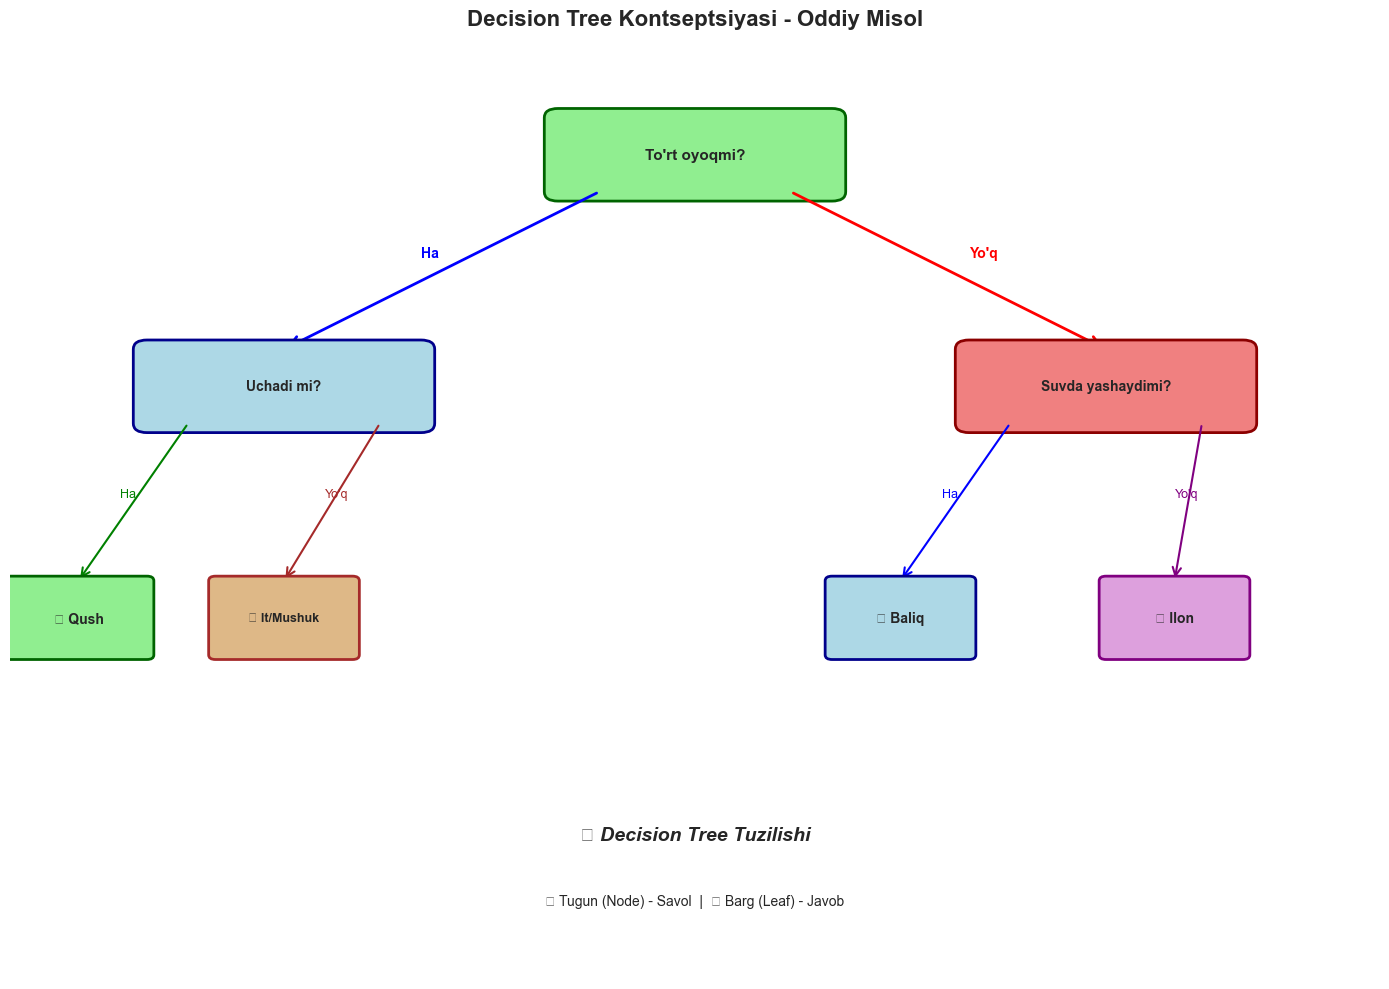

\n💡 Tushuntirish:
1. Root (ildiz) - Eng yuqoridagi savol
2. Internal Nodes - Oraliq savollar
3. Leaf Nodes - Yakuniy javoblar (class)
4. Har bir yo'l (path) - bitta qaror zanjiri


In [ ]:
# Decision Tree kontseptsiyasini vizualizatsiya qilish
# Oddiy misol: Hayvonlarni tasniflash

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Root node
root = FancyBboxPatch((4, 8.5), 2, 0.8, boxstyle="round,pad=0.1", 
                       edgecolor='darkgreen', facecolor='lightgreen', linewidth=2)
ax.add_patch(root)
ax.text(5, 8.9, 'To\'rt oyoqmi?', ha='center', va='center', fontsize=11, fontweight='bold')

# Left branch - Ha
arrow1 = FancyArrowPatch((4.3, 8.5), (2, 6.8), arrowstyle='->', 
                         mutation_scale=20, linewidth=2, color='blue')
ax.add_patch(arrow1)
ax.text(3, 7.8, 'Ha', fontsize=10, color='blue', fontweight='bold')

# Right branch - Yo'q  
arrow2 = FancyArrowPatch((5.7, 8.5), (8, 6.8),
                         arrowstyle='->', mutation_scale=20, linewidth=2, color='red')
ax.add_patch(arrow2)
ax.text(7, 7.8, 'Yo\'q', fontsize=10, color='red', fontweight='bold')

# Left node
left_node = FancyBboxPatch((1, 6), 2, 0.8, boxstyle="round,pad=0.1",
                           edgecolor='darkblue', facecolor='lightblue', linewidth=2)
ax.add_patch(left_node)
ax.text(2, 6.4, 'Uchadi mi?', ha='center', va='center', fontsize=10, fontweight='bold')

# Right node
right_node = FancyBboxPatch((7, 6), 2, 0.8, boxstyle="round,pad=0.1",
                            edgecolor='darkred', facecolor='lightcoral', linewidth=2)
ax.add_patch(right_node)
ax.text(8, 6.4, 'Suvda yashaydimi?', ha='center', va='center', fontsize=10, fontweight='bold')

# Leaf nodes (yakuniy javoblar)
# Qush
arrow3 = FancyArrowPatch((1.3, 6), (0.5, 4.3), arrowstyle='->', 
                         mutation_scale=15, linewidth=1.5, color='green')
ax.add_patch(arrow3)
ax.text(0.8, 5.2, 'Ha', fontsize=9, color='green')
leaf1 = FancyBboxPatch((0, 3.5), 1, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='darkgreen', facecolor='#90EE90', linewidth=2)
ax.add_patch(leaf1)
ax.text(0.5, 3.9, '🦅 Qush', ha='center', va='center', fontsize=10, fontweight='bold')

# It/Mushuk
arrow4 = FancyArrowPatch((2.7, 6), (2, 4.3), arrowstyle='->', 
                         mutation_scale=15, linewidth=1.5, color='brown')
ax.add_patch(arrow4)
ax.text(2.3, 5.2, 'Yo\'q', fontsize=9, color='brown')
leaf2 = FancyBboxPatch((1.5, 3.5), 1, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='brown', facecolor='#DEB887', linewidth=2)
ax.add_patch(leaf2)
ax.text(2, 3.9, '🐕 It/Mushuk', ha='center', va='center', fontsize=9, fontweight='bold')

# Baliq (chap)
arrow5 = FancyArrowPatch((7.3, 6), (6.5, 4.3), arrowstyle='->', 
                         mutation_scale=15, linewidth=1.5, color='blue')
ax.add_patch(arrow5)
ax.text(6.8, 5.2, 'Ha', fontsize=9, color='blue')
leaf3 = FancyBboxPatch((6, 3.5), 1, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='darkblue', facecolor='lightblue', linewidth=2)
ax.add_patch(leaf3)
ax.text(6.5, 3.9, '🐟 Baliq', ha='center', va='center', fontsize=10, fontweight='bold')

# Ilon
arrow6 = FancyArrowPatch((8.7, 6), (8.5, 4.3), arrowstyle='->', 
                         mutation_scale=15, linewidth=1.5, color='purple')
ax.add_patch(arrow6)
ax.text(8.5, 5.2, 'Yo\'q', fontsize=9, color='purple')
leaf4 = FancyBboxPatch((8, 3.5), 1, 0.8, boxstyle="round,pad=0.05",
                       edgecolor='purple', facecolor='plum', linewidth=2)
ax.add_patch(leaf4)
ax.text(8.5, 3.9, '🐍 Ilon', ha='center', va='center', fontsize=10, fontweight='bold')

# Legend
ax.text(5, 1.5, '🌳 Decision Tree Tuzilishi', ha='center', fontsize=14, 
        fontweight='bold', style='italic')
ax.text(5, 0.8, '🔵 Tugun (Node) - Savol  |  🔴 Barg (Leaf) - Javob', 
        ha='center', fontsize=10)

plt.title('Decision Tree Kontseptsiyasi - Oddiy Misol', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 Tushuntirish:")
print("1. Root (ildiz) - Eng yuqoridagi savol")
print("2. Internal Nodes - Oraliq savollar")  
print("3. Leaf Nodes - Yakuniy javoblar (class)")
print("4. Har bir yo'l (path) - bitta qaror zanjiri")

### 📊 Gini Impurity va Entropy ni Tushunish

Ikkalasi ham **node'ning "nopokligini"** (impurity) o'lchaydi.

**Pure Node (Pok tugun)**: Faqat bitta class  
**Impure Node (Nopok tugun)**: Aralash class'lar

Decision Tree **eng yaxshi split**ni topish uchun shu metrikalarni ishlatadi.

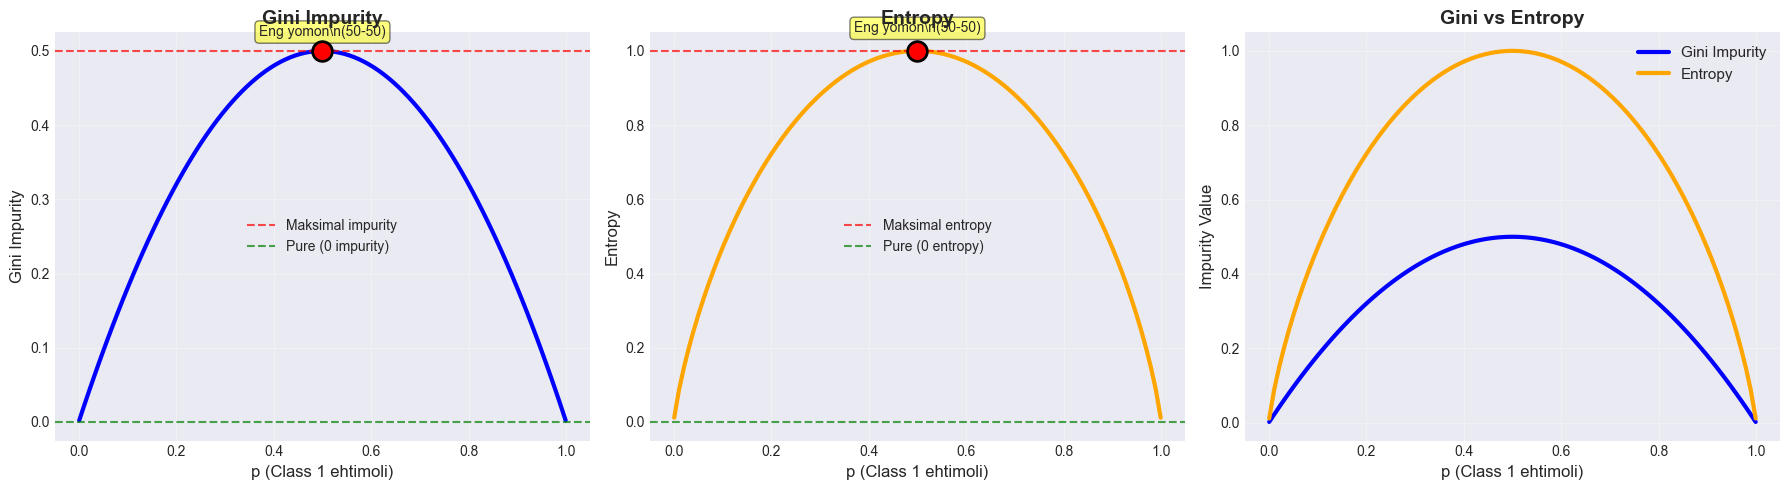

\n📊 Misollar:\n
Scenario 1: 100% bitta class (Pure)
  Gini: 0.0000
  Entropy: 0.0000
  ➡️ Eng yaxshi! Split kerak emas.\n
Scenario 2: 50-50 split (Maximum impurity)
  Gini: 0.5000
  Entropy: 1.0000
  ➡️ Eng yomon! Split kerak!\n
Scenario 3: 80-20 split
  Gini: 0.3200
  Entropy: 0.7219
  ➡️ O'rtacha. Split qilish mumkin.\n
💡 Xulosa:
- Past qiymat (0 ga yaqin) = Pure = Yaxshi!
- Yuqori qiymat = Impure = Yomon, split qilish kerak


In [ ]:
# Gini Impurity va Entropy Vizualizatsiya

def gini_impurity(p):
    """Gini = 1 - Σ(p_i²)"""
    return 1 - p**2 - (1-p)**2

def entropy(p):
    """Entropy = -Σ(p_i * log2(p_i))"""
    if p == 0 or p == 1:
        return 0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# Probability range (0 to 1)
p = np.linspace(0.001, 0.999, 100)
gini = [gini_impurity(pi) for pi in p]
ent = [entropy(pi) for pi in p]

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gini Impurity
axes[0].plot(p, gini, linewidth=3, color='blue')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Maksimal impurity')
axes[0].axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Pure (0 impurity)')
axes[0].scatter([0.5], [0.5], s=200, c='red', zorder=5, edgecolors='black', linewidths=2)
axes[0].set_xlabel('p (Class 1 ehtimoli)', fontsize=12)
axes[0].set_ylabel('Gini Impurity', fontsize=12)
axes[0].set_title('Gini Impurity', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].text(0.5, 0.52, 'Eng yomon\n(50-50)', ha='center', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# 2. Entropy
axes[1].plot(p, ent, linewidth=3, color='orange')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Maksimal entropy')
axes[1].axhline(y=0, color='green', linestyle='--', alpha=0.7, label='Pure (0 entropy)')
axes[1].scatter([0.5], [1], s=200, c='red', zorder=5, edgecolors='black', linewidths=2)
axes[1].set_xlabel('p (Class 1 ehtimoli)', fontsize=12)
axes[1].set_ylabel('Entropy', fontsize=12)
axes[1].set_title('Entropy', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].text(0.5, 1.05, 'Eng yomon\n(50-50)', ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# 3. Comparison
axes[2].plot(p, gini, linewidth=3, label='Gini Impurity', color='blue')
axes[2].plot(p, ent, linewidth=3, label='Entropy', color='orange')
axes[2].set_xlabel('p (Class 1 ehtimoli)', fontsize=12)
axes[2].set_ylabel('Impurity Value', fontsize=12)
axes[2].set_title('Gini vs Entropy', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Misollar
print("\n📊 Misollar:\n")
print("Scenario 1: 100% bitta class (Pure)")
print(f"  Gini: {gini_impurity(1.0):.4f}")
print(f"  Entropy: {entropy(1.0):.4f}")
print("  ➡️ Eng yaxshi! Split kerak emas.\n")

print("Scenario 2: 50-50 split (Maximum impurity)")
print(f"  Gini: {gini_impurity(0.5):.4f}")
print(f"  Entropy: {entropy(0.5):.4f}")
print("  ➡️ Eng yomon! Split kerak!\n")

print("Scenario 3: 80-20 split")
print(f"  Gini: {gini_impurity(0.8):.4f}")
print(f"  Entropy: {entropy(0.8):.4f}")
print("  ➡️ O'rtacha. Split qilish mumkin.\n")

print("💡 Xulosa:")
print("- Past qiymat (0 ga yaqin) = Pure = Yaxshi!")
print("- Yuqori qiymat = Impure = Yomon, split qilish kerak")

### 🎯 Decision Tree Split Jarayoni

Keling, Decision Tree qanday ishlashini qadam-baqadam ko'raylik.

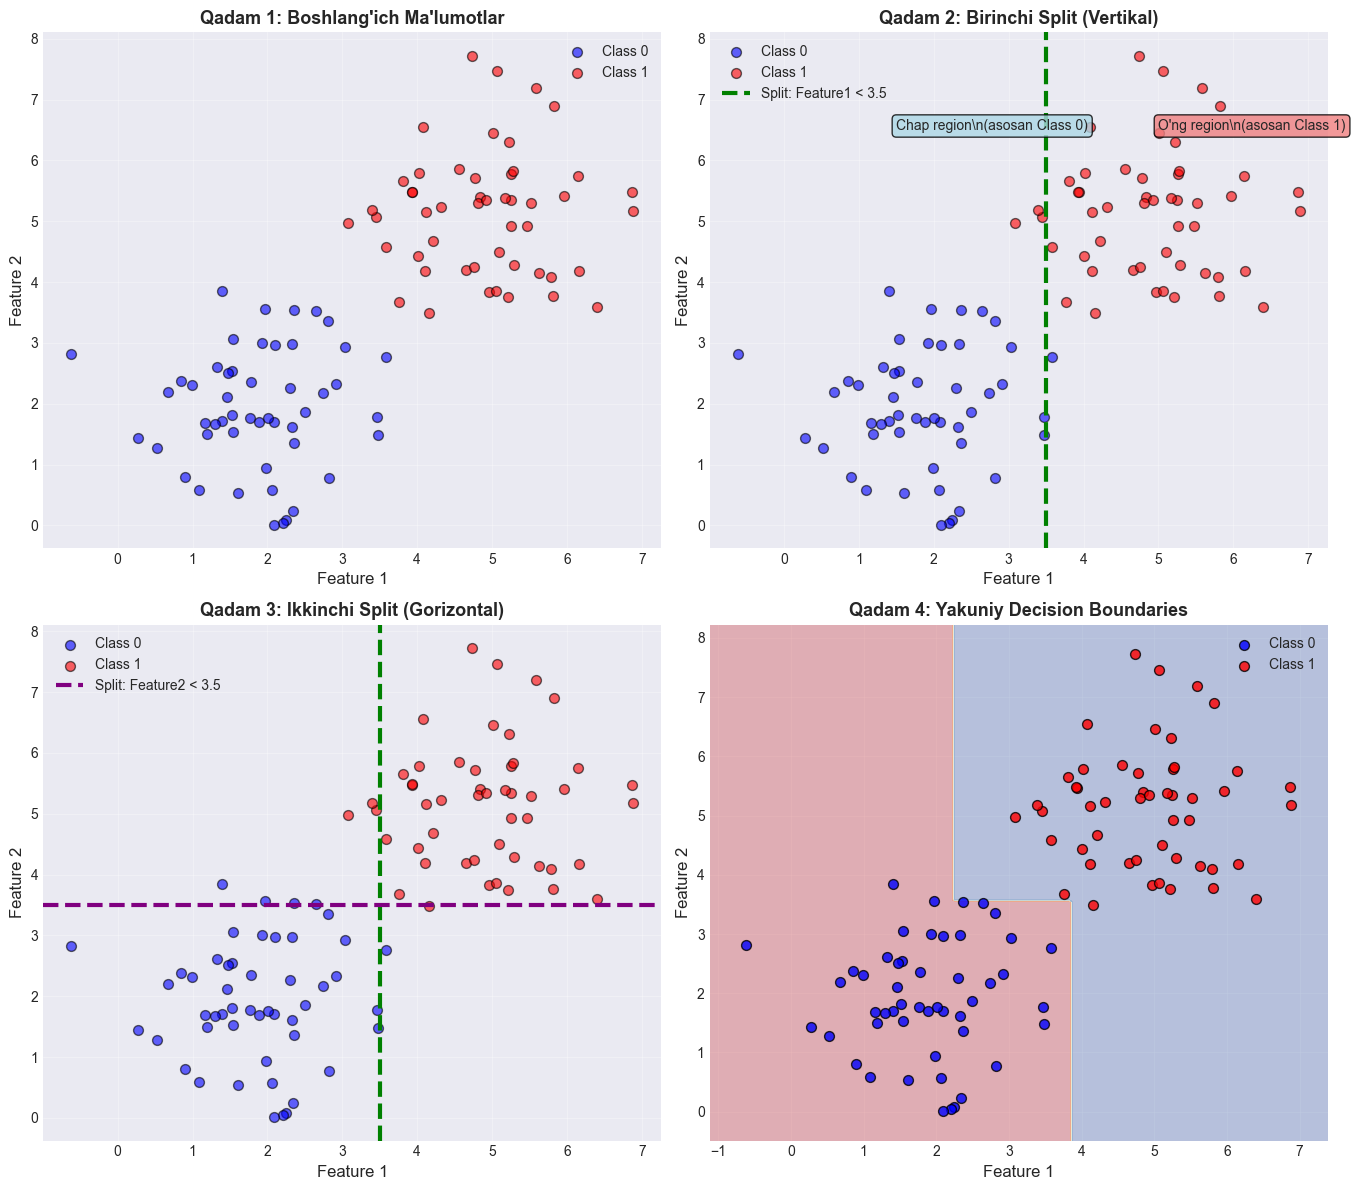

\n🌳 Decision Tree Split Jarayoni:
1️⃣ Boshlang'ich: Barcha ma'lumotlar bitta node'da
2️⃣ Feature 1 bo'yicha split: Ma'lumotlarni 2 ga ajratish
3️⃣ Feature 2 bo'yicha split: Har bir qismni yana ajratish
4️⃣ Yakuniy: Har bir region bitta class'ga tegishli
\n💡 Decision Tree to'rtburchak region'lar hosil qiladi!
   (Faqat vertikal va gorizontal chiziqlar)


In [ ]:
# Decision Tree Split Process Visualization
np.random.seed(42)

# Oddiy 2D data yaratish
n_samples = 100
X1 = np.random.randn(n_samples//2, 2) + [2, 2]  # Class 0
X2 = np.random.randn(n_samples//2, 2) + [5, 5]  # Class 1
X_split = np.vstack([X1, X2])
y_split = np.hstack([np.zeros(n_samples//2), np.ones(n_samples//2)])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Original Data
axes[0, 0].scatter(X_split[y_split==0, 0], X_split[y_split==0, 1], 
                   c='blue', s=50, alpha=0.6, label='Class 0', edgecolors='black')
axes[0, 0].scatter(X_split[y_split==1, 0], X_split[y_split==1, 1], 
                   c='red', s=50, alpha=0.6, label='Class 1', edgecolors='black')
axes[0, 0].set_xlabel('Feature 1', fontsize=12)
axes[0, 0].set_ylabel('Feature 2', fontsize=12)
axes[0, 0].set_title('Qadam 1: Boshlang\'ich Ma\'lumotlar', fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. First Split (Feature 1 < 3.5)
split_point = 3.5
axes[0, 1].scatter(X_split[y_split==0, 0], X_split[y_split==0, 1], 
                   c='blue', s=50, alpha=0.6, label='Class 0', edgecolors='black')
axes[0, 1].scatter(X_split[y_split==1, 0], X_split[y_split==1, 1], 
                   c='red', s=50, alpha=0.6, label='Class 1', edgecolors='black')
axes[0, 1].axvline(x=split_point, color='green', linewidth=3, linestyle='--', 
                   label=f'Split: Feature1 < {split_point}')
axes[0, 1].set_xlabel('Feature 1', fontsize=12)
axes[0, 1].set_ylabel('Feature 2', fontsize=12)
axes[0, 1].set_title('Qadam 2: Birinchi Split (Vertikal)', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(1.5, 6.5, 'Chap region\n(asosan Class 0)', fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[0, 1].text(5, 6.5, 'O\'ng region\n(asosan Class 1)', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

# 3. Second Split (Feature 2 < 3.5)
split_point2 = 3.5
axes[1, 0].scatter(X_split[y_split==0, 0], X_split[y_split==0, 1], 
                   c='blue', s=50, alpha=0.6, label='Class 0', edgecolors='black')
axes[1, 0].scatter(X_split[y_split==1, 0], X_split[y_split==1, 1], 
                   c='red', s=50, alpha=0.6, label='Class 1', edgecolors='black')
axes[1, 0].axvline(x=split_point, color='green', linewidth=3, linestyle='--')
axes[1, 0].axhline(y=split_point2, color='purple', linewidth=3, linestyle='--',
                   label=f'Split: Feature2 < {split_point2}')
axes[1, 0].set_xlabel('Feature 1', fontsize=12)
axes[1, 0].set_ylabel('Feature 2', fontsize=12)
axes[1, 0].set_title('Qadam 3: Ikkinchi Split (Gorizontal)', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Decision Boundaries
from sklearn.tree import DecisionTreeClassifier
dt_visual = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_visual.fit(X_split, y_split)

# Create mesh
x_min, x_max = X_split[:, 0].min() - 0.5, X_split[:, 0].max() + 0.5
y_min, y_max = X_split[:, 1].min() - 0.5, X_split[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = dt_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[1, 1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
axes[1, 1].scatter(X_split[y_split==0, 0], X_split[y_split==0, 1], 
                   c='blue', s=50, alpha=0.8, label='Class 0', edgecolors='black', linewidth=1)
axes[1, 1].scatter(X_split[y_split==1, 0], X_split[y_split==1, 1], 
                   c='red', s=50, alpha=0.8, label='Class 1', edgecolors='black', linewidth=1)
axes[1, 1].set_xlabel('Feature 1', fontsize=12)
axes[1, 1].set_ylabel('Feature 2', fontsize=12)
axes[1, 1].set_title('Qadam 4: Yakuniy Decision Boundaries', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🌳 Decision Tree Split Jarayoni:")
print("=" * 60)
print("1️⃣ Boshlang'ich: Barcha ma'lumotlar bitta node'da")
print("2️⃣ Feature 1 bo'yicha split: Ma'lumotlarni 2 ga ajratish")
print("3️⃣ Feature 2 bo'yicha split: Har bir qismni yana ajratish")
print("4️⃣ Yakuniy: Har bir region bitta class'ga tegishli")
print("=" * 60)
print("\n💡 Decision Tree to'rtburchak region'lar hosil qiladi!")
print("   (Faqat vertikal va gorizontal chiziqlar)")

### 4.5. Decision Tree'ni vizualizatsiya qilish

Decision Tree modelining eng kuchli jihati - uni vizualizatsiya qilish mumkin. Bu sizga model qanday qaror qabul qilayotganini aniq ko'rish imkonini beradi.

Endi Iris ma'lumotlar to'plamida o'rgatilgan Decision Tree'ni ko'ramiz va uni vizualizatsiya qilamiz.

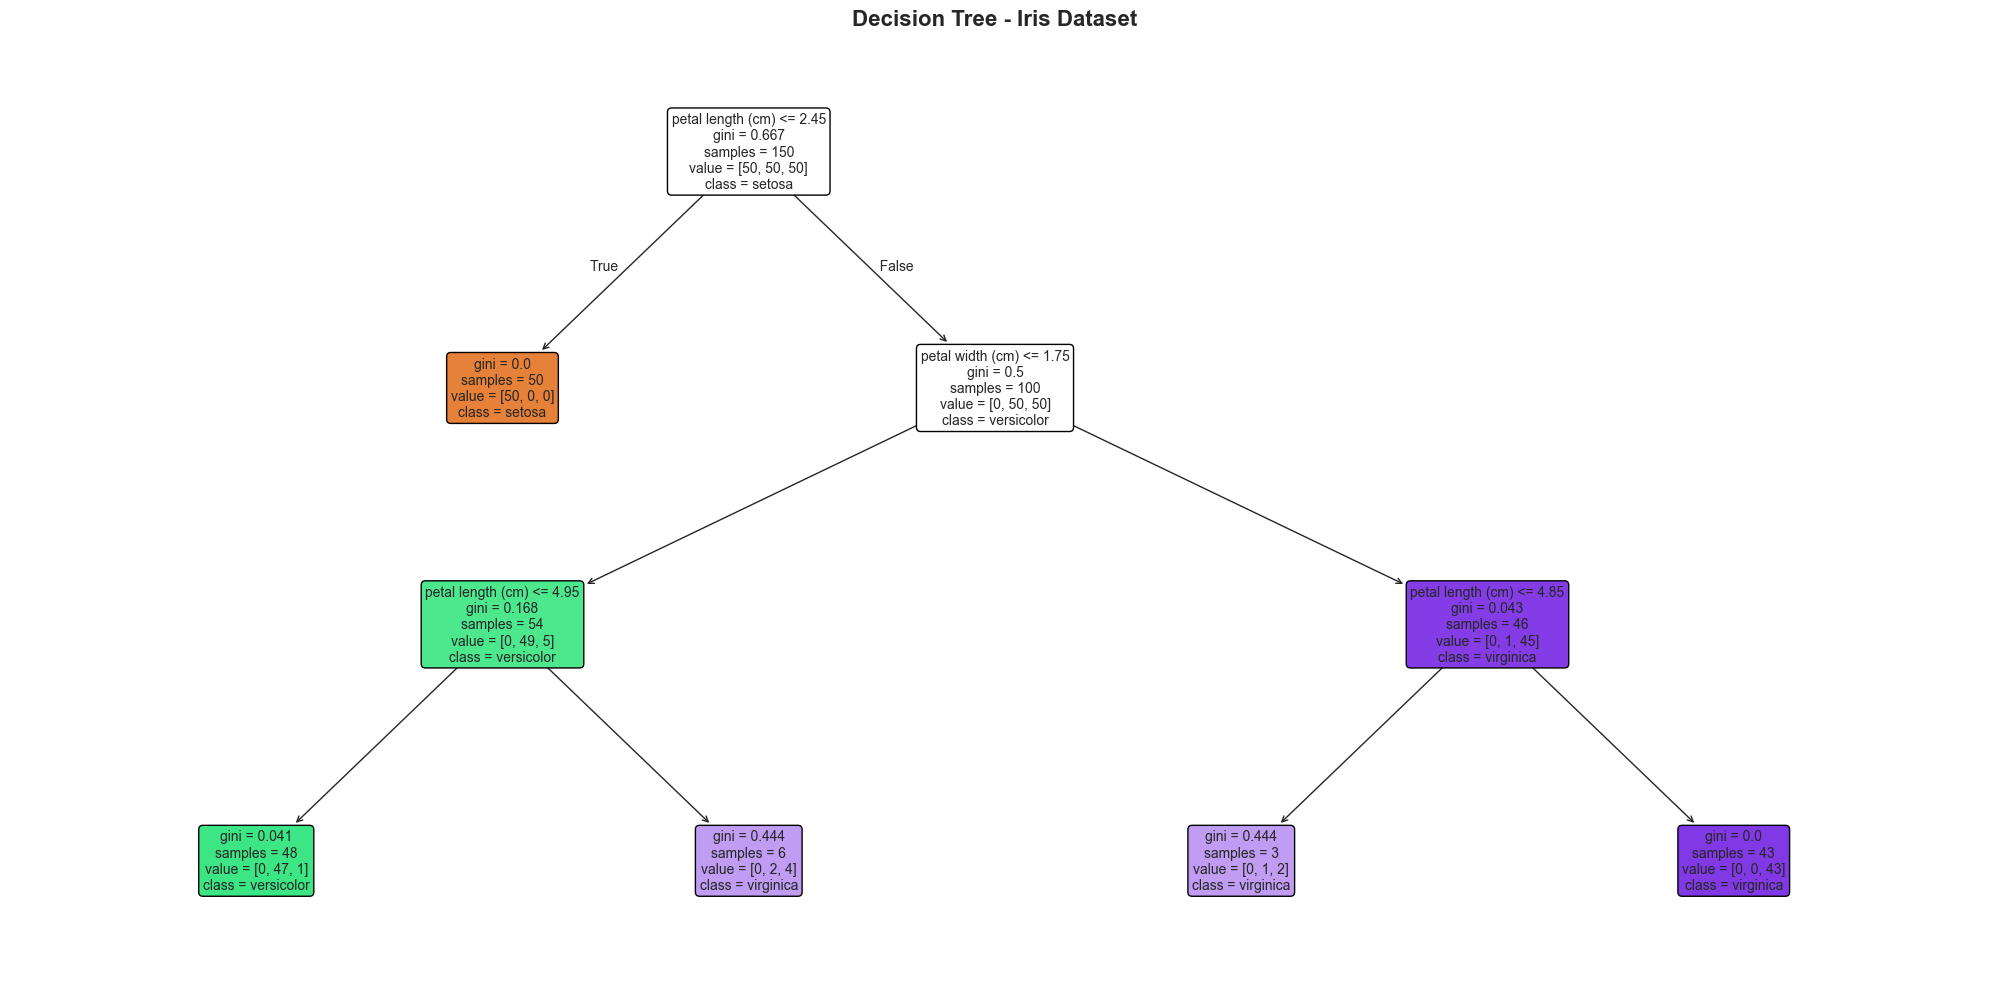

Model aniqligi: 0.9733


In [20]:
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Iris ma'lumotlar to'plamini yuklaymiz
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Decision Tree modelini yaratamiz va o'rgatamiz
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_iris, y_iris)

# Decision Tree'ni vizualizatsiya qilamiz
plt.figure(figsize=(20, 10))
plot_tree(dt, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree - Iris Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Model aniqligi: {dt.score(X_iris, y_iris):.4f}")

In [46]:
# Decision Tree modeli (Iris dataset)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_i, y_train_i)  # Scaling shart emas!

# Bashorat
y_pred_dt = dt.predict(X_test_i)

# Baholash
accuracy_dt = accuracy_score(y_test_i, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_dt, target_names=iris.target_names))

Decision Tree Accuracy: 0.9667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



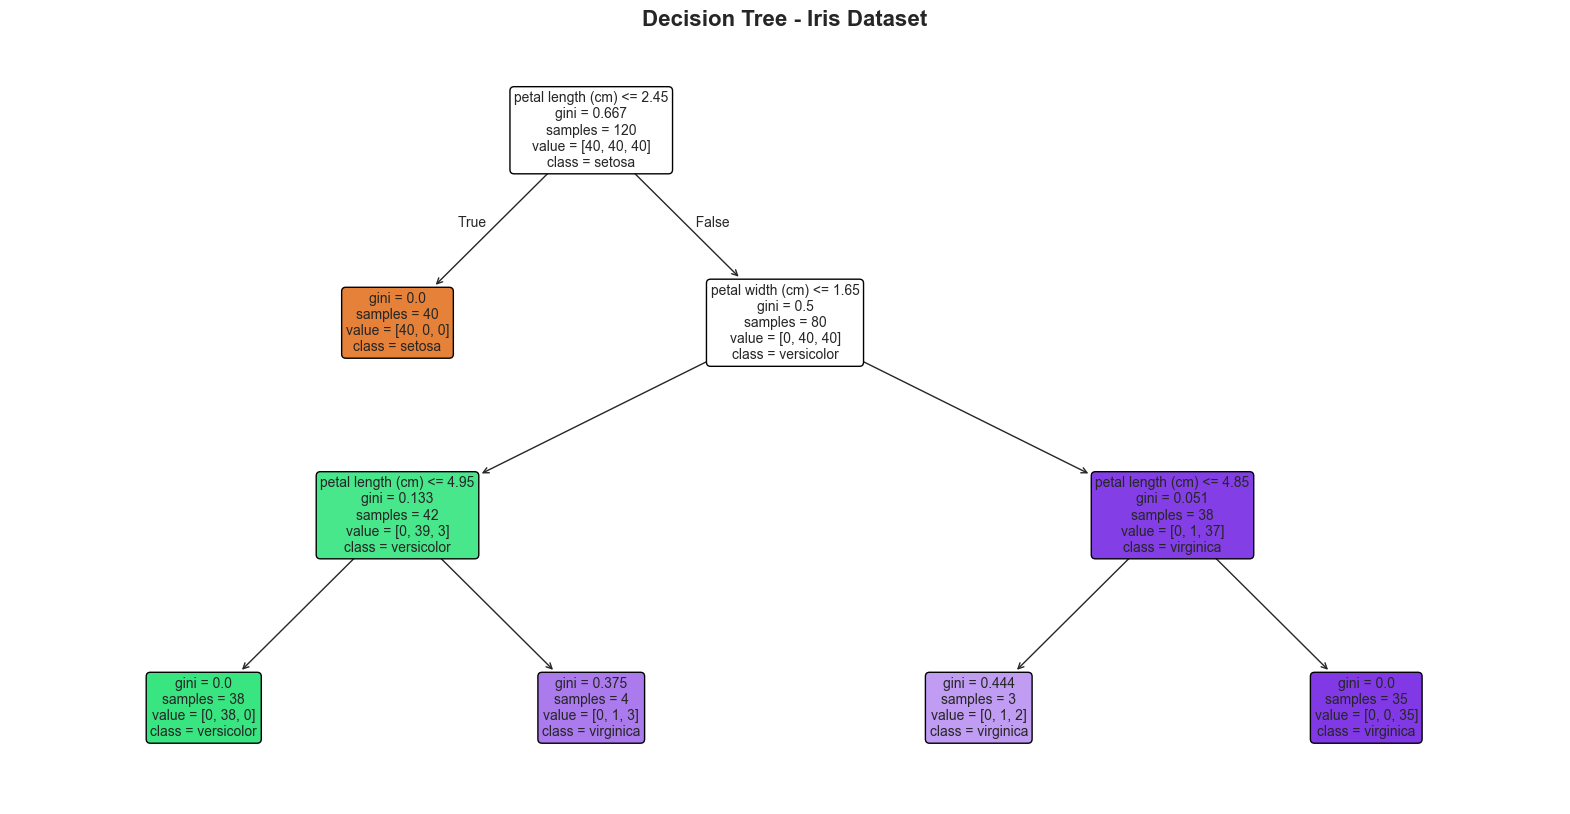

In [47]:
# Decision Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(dt, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree - Iris Dataset', fontsize=16, fontweight='bold')
plt.show()

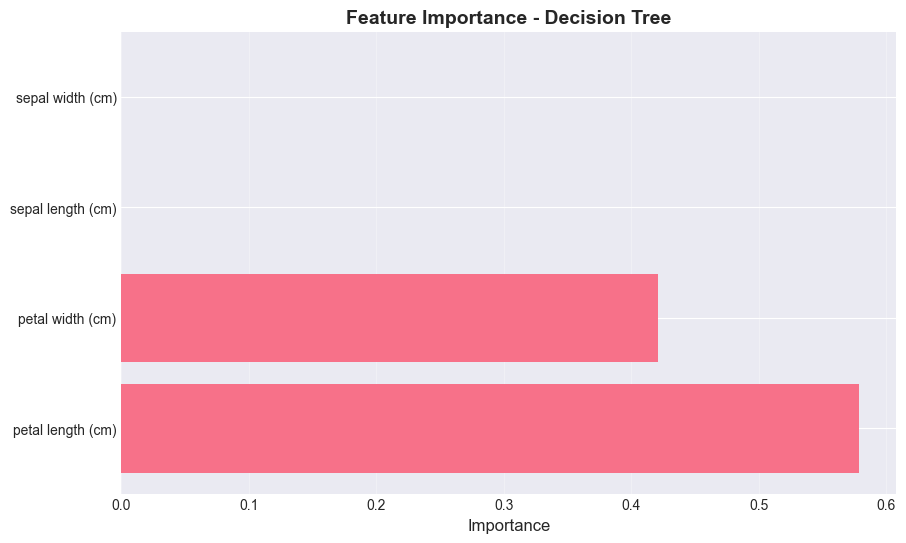

Feature Importance:
             feature  importance
2  petal length (cm)    0.579077
3   petal width (cm)    0.420923
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.000000


In [48]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.show()

print("Feature Importance:")
print(feature_importance)

### Decision Tree: Overfitting muammosi

**Muammo**: Decision Tree juda chuqur bo'lsa, training data'ni 100% o'rganadi (overfitting).

**Yechimlar**:
1. **max_depth**: Daraxt chuqurligini cheklash
2. **min_samples_split**: Node'ni split qilish uchun minimal namunalar
3. **min_samples_leaf**: Leaf node'da minimal namunalar
4. **max_leaf_nodes**: Maksimal leaf node'lar soni
5. **Pruning**: Daraxtni qisqartirish

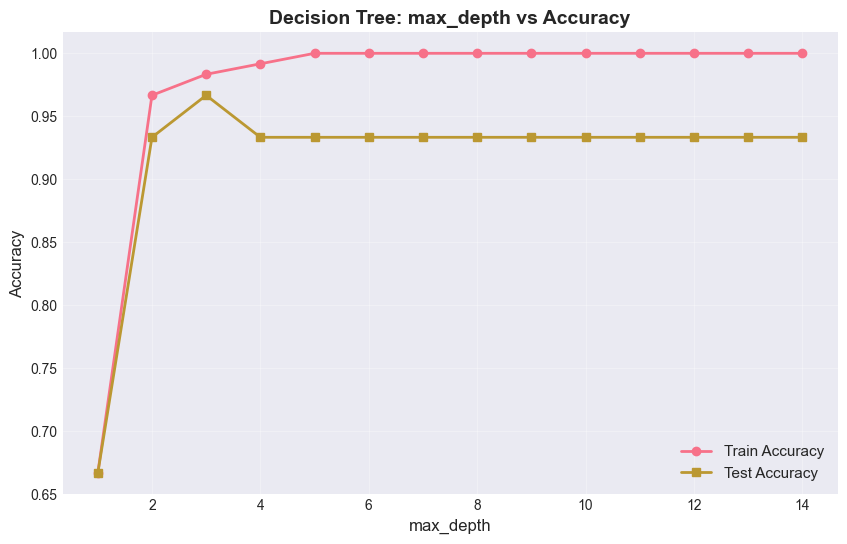

Eng yaxshi max_depth: 3
Test Accuracy: 0.9667


In [49]:
# Overfitting vs Regularization
depths = range(1, 15)
train_scores_dt = []
test_scores_dt = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train_i, y_train_i)
    
    train_scores_dt.append(dt_temp.score(X_train_i, y_train_i))
    test_scores_dt.append(dt_temp.score(X_test_i, y_test_i))

# Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores_dt, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(depths, test_scores_dt, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Decision Tree: max_depth vs Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

best_depth = depths[np.argmax(test_scores_dt)]
print(f"Eng yaxshi max_depth: {best_depth}")
print(f"Test Accuracy: {max(test_scores_dt):.4f}")

---

# 4️⃣ Random Forest

## 📖 Nazariya

**Random Forest** - ko'plab Decision Tree'larning **ensemble**i (jamlanmasi).

### Asosiy G'oya:
"Wisdom of the crowd" - ko'p tree'larning fikri bitta tree'dan yaxshi!

### Algoritm:
1. **Bootstrap Sampling**: Har bir tree uchun random sample (with replacement)
2. **Random Feature Selection**: Har bir split'da random feature'lar subset
3. **Build Trees**: Har bir tree'ni to'liq o'sishi (max_depth yo'q)
4. **Voting**: Barcha tree'larning bashoratlaridan ko'pchilik ovozi

### Terminologiya:
- **Bagging**: Bootstrap Aggregating
- **Out-of-Bag (OOB)**: Har bir tree training'da ishlatilmagan ~37% data
- **n_estimators**: Tree'lar soni

### 🌲 Random Forest: Ensemble Kontseptsiyasi

Random Forest - bu ko'plab Decision Tree'larning **ensemble**i (jamlangan kuchi). 

**"Wisdom of the Crowd"** - bir guruh odamlarning umumiy fikri bitta odamning fikridan ko'proq to'g'ri bo'ladi!

Keling, buni vizualizatsiya qilamiz:

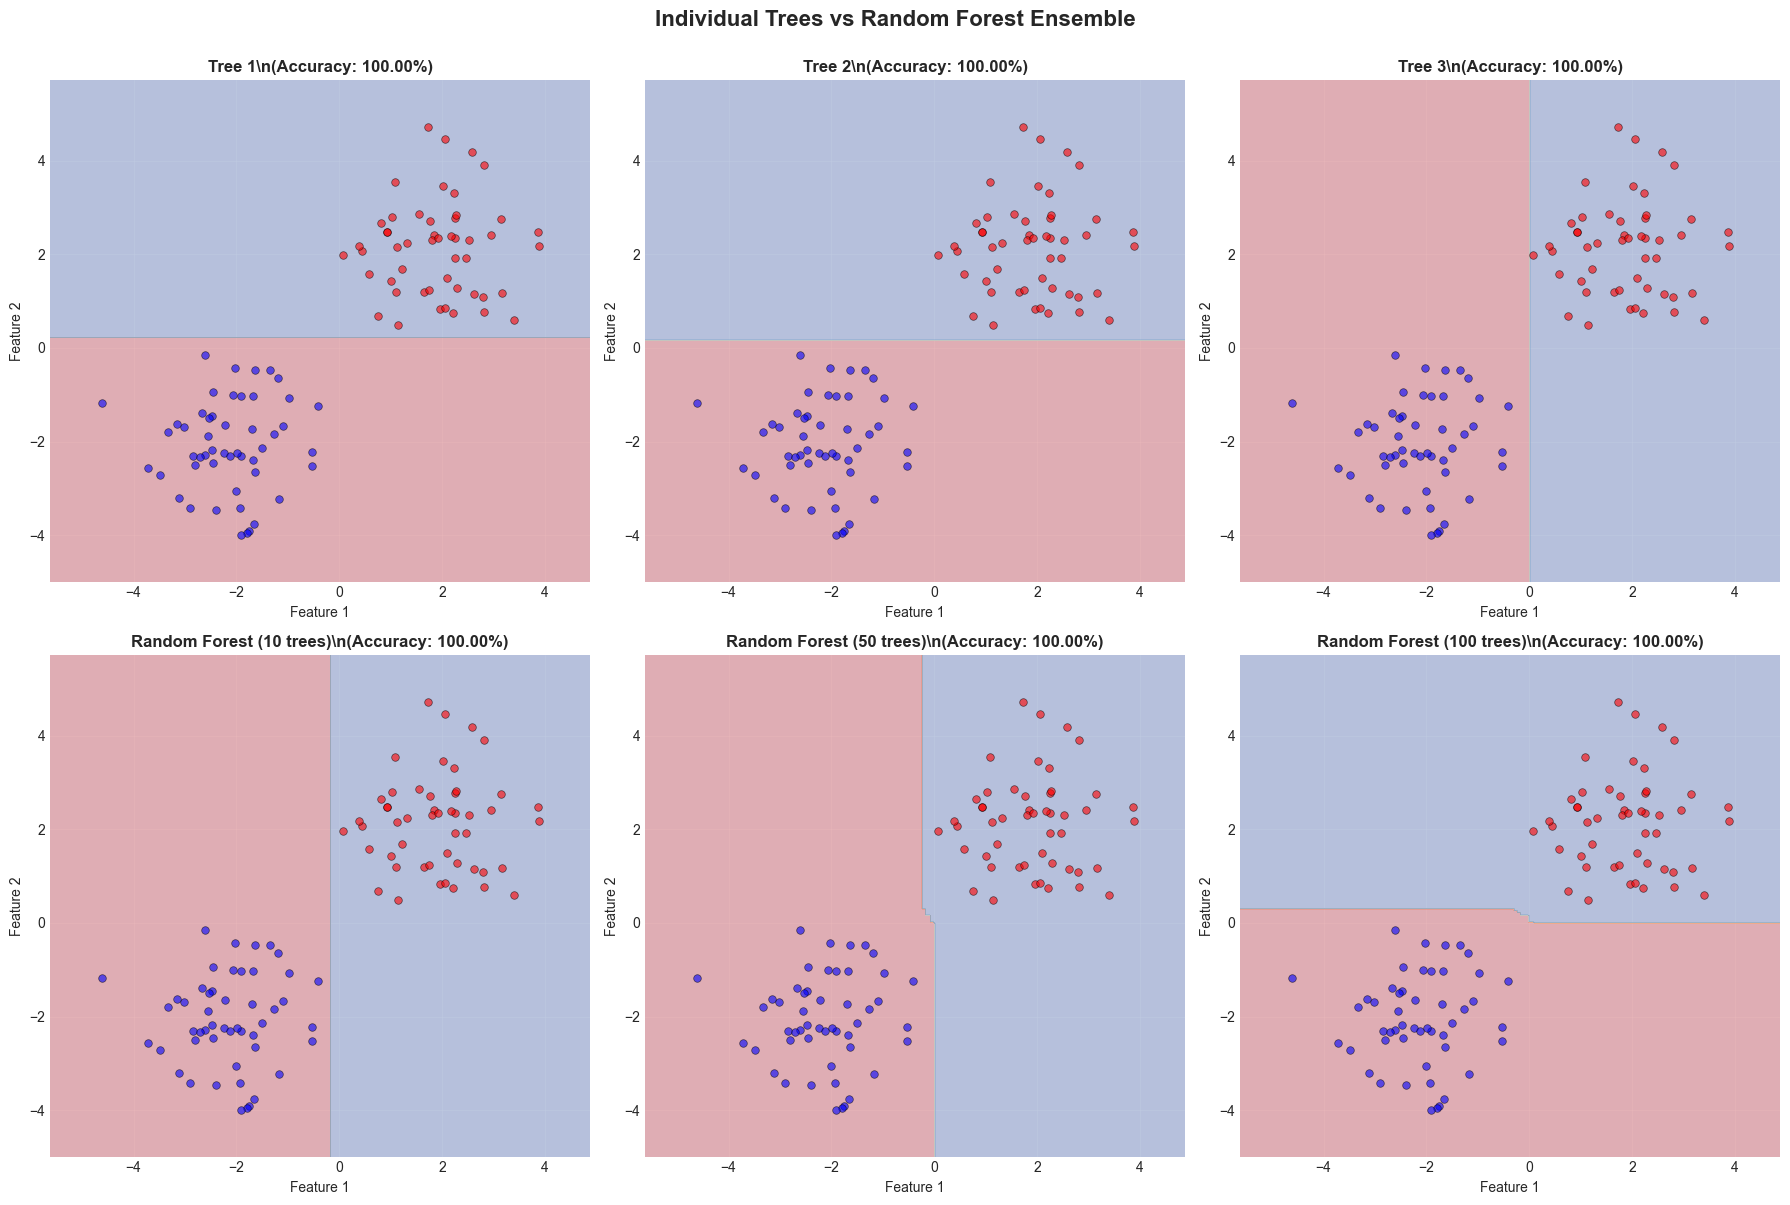

\n======================================================================
RANDOM FOREST: ENSEMBLE KUCHI
\n🌳 Individual Decision Trees:
  - Har bir tree turlicha boundary yaratadi
  - Ba'zilari yaxshi, ba'zilari yomon
  - Overfitting'ga moyil
\n🌲 Random Forest (Ensemble):
  - Ko'p tree'larning ovozlari birlashtiriladi
  - Smooth va barqaror boundary
  - Overfitting kamaytiradi
  - Tree'lar soni ko'paygan sari yaxshiroq!
\n💡 Asosiy g'oya:
  Bitta 'expert' (tree) xato qilishi mumkin,
  lekin ko'p 'expert'larning umumiy fikri to'g'riroq!


In [ ]:
# Random Forest Ensemble Visualization
from sklearn.tree import DecisionTreeClassifier

# Oddiy 2D data
np.random.seed(42)
X_rf_demo = np.vstack([
    np.random.randn(50, 2) + [-2, -2],
    np.random.randn(50, 2) + [2, 2]
])
y_rf_demo = np.hstack([np.zeros(50), np.ones(50)])

# 1 Decision Tree vs Random Forest
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Birinchi qator: 3 ta individual Decision Tree
for i in range(3):
    # Bootstrap sample
    indices = np.random.choice(len(X_rf_demo), len(X_rf_demo), replace=True)
    X_bootstrap = X_rf_demo[indices]
    y_bootstrap = y_rf_demo[indices]
    
    # Decision Tree
    dt_single = DecisionTreeClassifier(max_depth=5, random_state=i)
    dt_single.fit(X_bootstrap, y_bootstrap)
    
    # Decision boundary
    h = 0.02
    x_min_rf, x_max_rf = X_rf_demo[:, 0].min() - 1, X_rf_demo[:, 0].max() + 1
    y_min_rf, y_max_rf = X_rf_demo[:, 1].min() - 1, X_rf_demo[:, 1].max() + 1
    xx_rf, yy_rf = np.meshgrid(np.arange(x_min_rf, x_max_rf, h),
                                np.arange(y_min_rf, y_max_rf, h))
    
    Z_single = dt_single.predict(np.c_[xx_rf.ravel(), yy_rf.ravel()])
    Z_single = Z_single.reshape(xx_rf.shape)
    
    # Plot
    axes[0, i].contourf(xx_rf, yy_rf, Z_single, alpha=0.3, cmap='RdYlBu')
    axes[0, i].scatter(X_rf_demo[y_rf_demo==0, 0], X_rf_demo[y_rf_demo==0, 1], 
                       c='blue', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[0, i].scatter(X_rf_demo[y_rf_demo==1, 0], X_rf_demo[y_rf_demo==1, 1], 
                       c='red', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    accuracy_single = dt_single.score(X_rf_demo, y_rf_demo)
    axes[0, i].set_title(f'Tree {i+1}\n(Accuracy: {accuracy_single:.2%})', 
                         fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('Feature 1', fontsize=10)
    axes[0, i].set_ylabel('Feature 2', fontsize=10)
    axes[0, i].grid(True, alpha=0.3)

# Ikkinchi qator: Random Forest (10, 50, 100 trees)
n_estimators_list = [10, 50, 100]

for idx, n_est in enumerate(n_estimators_list):
    rf_visual = RandomForestClassifier(n_estimators=n_est, max_depth=5, random_state=42)
    rf_visual.fit(X_rf_demo, y_rf_demo)
    
    Z_rf = rf_visual.predict(np.c_[xx_rf.ravel(), yy_rf.ravel()])
    Z_rf = Z_rf.reshape(xx_rf.shape)
    
    # Plot
    axes[1, idx].contourf(xx_rf, yy_rf, Z_rf, alpha=0.3, cmap='RdYlBu')
    axes[1, idx].scatter(X_rf_demo[y_rf_demo==0, 0], X_rf_demo[y_rf_demo==0, 1], 
                         c='blue', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
    axes[1, idx].scatter(X_rf_demo[y_rf_demo==1, 0], X_rf_demo[y_rf_demo==1, 1], 
                         c='red', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    accuracy_rf_visual = rf_visual.score(X_rf_demo, y_rf_demo)
    axes[1, idx].set_title(f'Random Forest ({n_est} trees)\n(Accuracy: {accuracy_rf_visual:.2%})', 
                           fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Feature 1', fontsize=10)
    axes[1, idx].set_ylabel('Feature 2', fontsize=10)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Individual Trees vs Random Forest Ensemble', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("RANDOM FOREST: ENSEMBLE KUCHI")
print("="*70)
print("\n🌳 Individual Decision Trees:")
print("  - Har bir tree turlicha boundary yaratadi")
print("  - Ba'zilari yaxshi, ba'zilari yomon")
print("  - Overfitting'ga moyil")

print("\n🌲 Random Forest (Ensemble):")
print("  - Ko'p tree'larning ovozlari birlashtiriladi")
print("  - Smooth va barqaror boundary")
print("  - Overfitting kamaytiradi")
print("  - Tree'lar soni ko'paygan sari yaxshiroq!")

print("\n💡 Asosiy g'oya:")
print("  Bitta 'expert' (tree) xato qilishi mumkin,")
print("  lekin ko'p 'expert'larning umumiy fikri to'g'riroq!")
print("="*70)

### 🎲 Bootstrap Sampling va Random Feature Selection

Random Forest'ning **Random** qismi 2 ta joyda:

1. **Bootstrap Sampling**: Har bir tree uchun random sample (with replacement)
2. **Random Feature Selection**: Har bir split'da random feature'lar

Bu diversity (turlilik) yaratadi va overfitting'ni kamaytiradi.

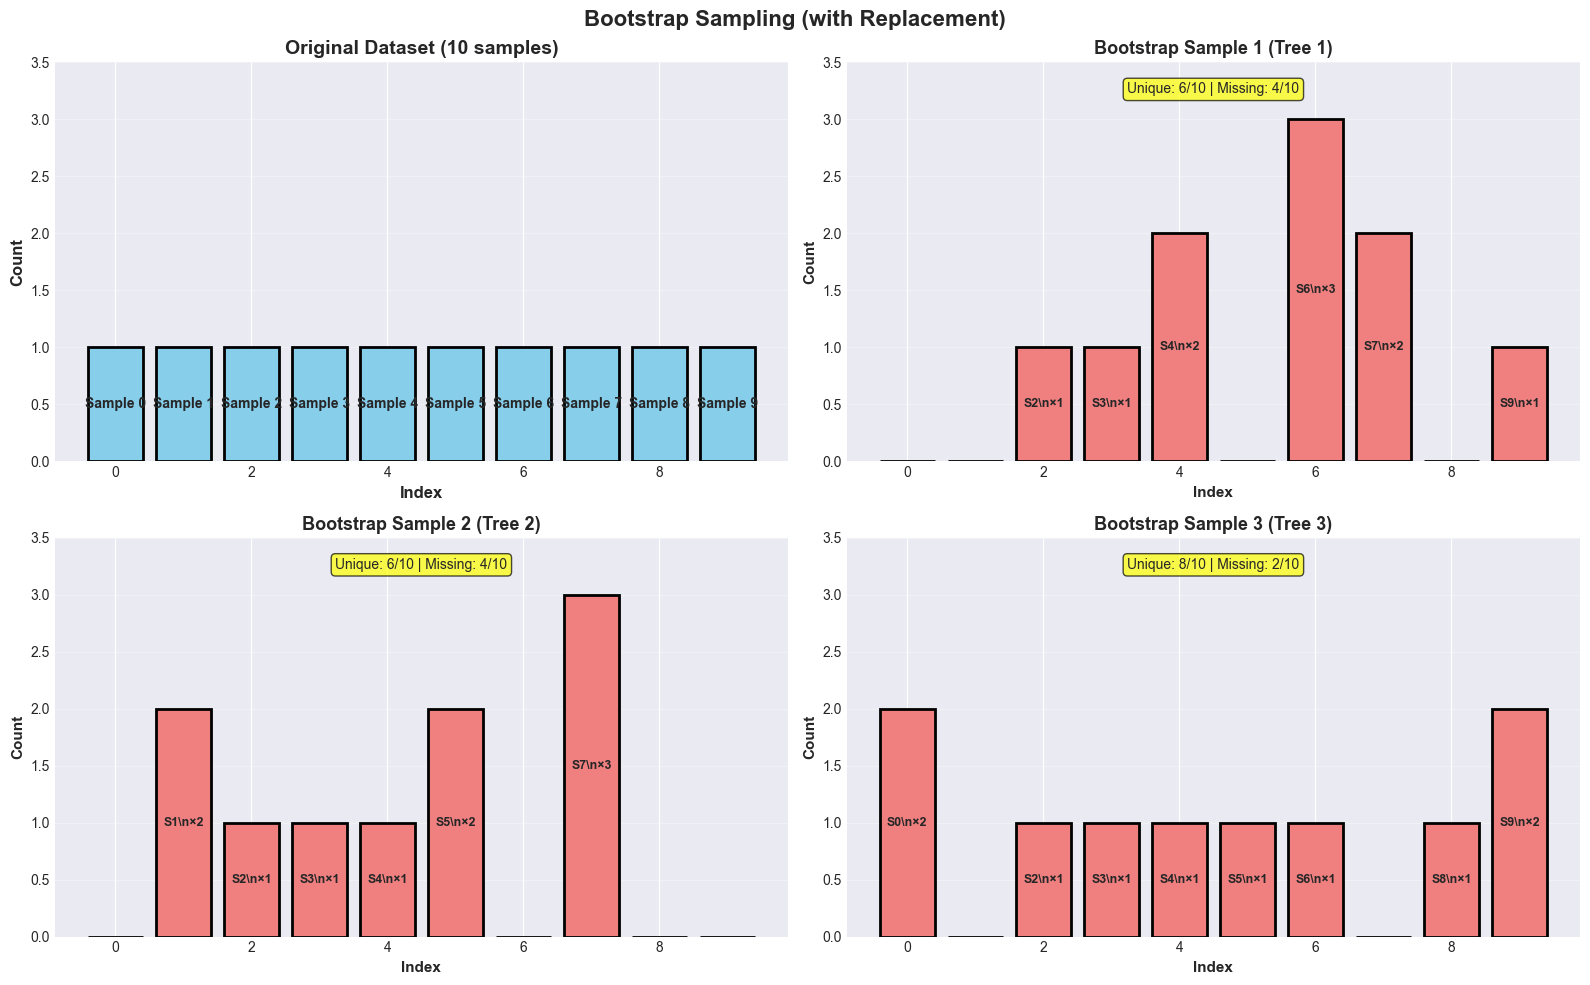

\n======================================================================
BOOTSTRAP SAMPLING TUSHUNTIRISH
\n📊 Original Dataset: 10 ta sample
\n🎲 Bootstrap Sample (with replacement):
  - 10 ta sample tanlanadi
  - Har bir sample bir necha marta tanlanishi mumkin
  - Ba'zi sample'lar umuman tanlanmasligi mumkin
  - O'rtacha ~63% unique samples, ~37% duplicates
\n🌲 Random Forest:
  - Har bir tree uchun alohida bootstrap sample
  - Har bir tree turlicha data'da o'rganadi
  - Bu diversity (turlilik) yaratadi
  - Overfitting kamayadi!
\n💡 Out-of-Bag (OOB) samples:
  - Tanlanmagan ~37% samples
  - Validation uchun ishlatiladi (free!)


In [ ]:
# Bootstrap Sampling Visualization
np.random.seed(42)

# Original dataset (kichik misolda)
original_indices = np.arange(10)
original_data = np.array([f'Sample {i}' for i in original_indices])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original Dataset
axes[0, 0].bar(original_indices, np.ones(10), color='skyblue', edgecolor='black', linewidth=2)
for i, label in enumerate(original_data):
    axes[0, 0].text(i, 0.5, label, ha='center', va='center', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('Index', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Original Dataset (10 samples)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim(0, 3.5)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Bootstrap Samples (3 ta misol)
for i in range(3):
    row = (i + 1) // 2
    col = (i + 1) % 2
    
    # Bootstrap sample (with replacement)
    bootstrap_indices = np.random.choice(original_indices, size=10, replace=True)
    unique, counts = np.unique(bootstrap_indices, return_counts=True)
    
    # Plot
    colors = ['lightcoral' if idx in bootstrap_indices else 'lightgray' for idx in original_indices]
    bars = axes[row, col].bar(original_indices, [counts[np.where(unique==idx)[0][0]] if idx in unique else 0 
                                                   for idx in original_indices], 
                               color=colors, edgecolor='black', linewidth=2)
    
    # Labels
    for idx in original_indices:
        count = counts[np.where(unique==idx)[0][0]] if idx in unique else 0
        if count > 0:
            axes[row, col].text(idx, count/2, f'S{idx}\n×{count}', 
                                ha='center', va='center', fontsize=9, fontweight='bold')
    
    axes[row, col].set_xlabel('Index', fontsize=11, fontweight='bold')
    axes[row, col].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'Bootstrap Sample {i+1} (Tree {i+1})', fontsize=13, fontweight='bold')
    axes[row, col].set_ylim(0, 3.5)
    axes[row, col].grid(True, alpha=0.3, axis='y')
    
    # Statistics
    n_unique = len(unique)
    n_missing = 10 - n_unique
    axes[row, col].text(0.5, 0.95, f'Unique: {n_unique}/10 | Missing: {n_missing}/10', 
                        transform=axes[row, col].transAxes, ha='center', va='top',
                        fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.suptitle('Bootstrap Sampling (with Replacement)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("BOOTSTRAP SAMPLING TUSHUNTIRISH")
print("="*70)
print("\n📊 Original Dataset: 10 ta sample")
print("\n🎲 Bootstrap Sample (with replacement):")
print("  - 10 ta sample tanlanadi")
print("  - Har bir sample bir necha marta tanlanishi mumkin")
print("  - Ba'zi sample'lar umuman tanlanmasligi mumkin")
print("  - O'rtacha ~63% unique samples, ~37% duplicates")

print("\n🌲 Random Forest:")
print("  - Har bir tree uchun alohida bootstrap sample")
print("  - Har bir tree turlicha data'da o'rganadi")
print("  - Bu diversity (turlilik) yaratadi")
print("  - Overfitting kamayadi!")

print("\n💡 Out-of-Bag (OOB) samples:")
print("  - Tanlanmagan ~37% samples")
print("  - Validation uchun ishlatiladi (free!)")
print("="*70)

In [52]:
# Random Forest modeli
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_i, y_train_i)

# Bashorat
y_pred_rf = rf.predict(X_test_i)

# Baholash
accuracy_rf = accuracy_score(y_test_i, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_i, y_pred_rf, target_names=iris.target_names))

Random Forest Accuracy: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



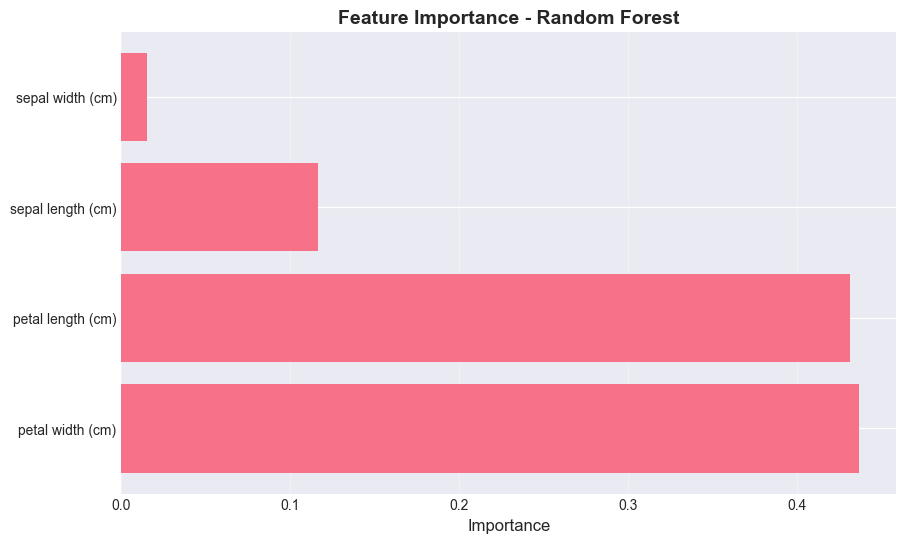

Feature Importance:
             feature  importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


In [53]:
# Feature Importance (Random Forest)
feature_importance_rf = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.show()

print("Feature Importance:")
print(feature_importance_rf)

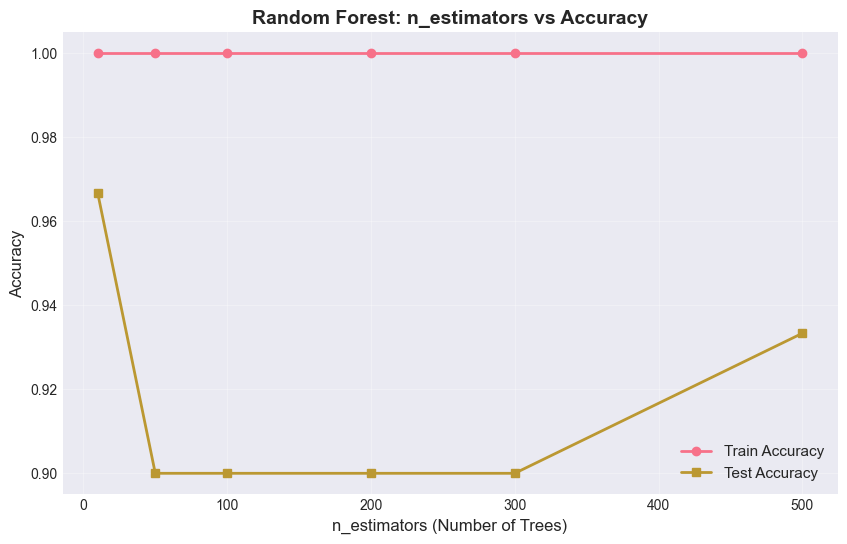

In [54]:
# n_estimators (tree'lar soni) ni tanlash
n_estimators_range = [10, 50, 100, 200, 300, 500]
train_scores_rf = []
test_scores_rf = []

for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_i, y_train_i)
    
    train_scores_rf.append(rf_temp.score(X_train_i, y_train_i))
    test_scores_rf.append(rf_temp.score(X_test_i, y_test_i))

# Vizualizatsiya
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores_rf, 'o-', label='Train Accuracy', linewidth=2)
plt.plot(n_estimators_range, test_scores_rf, 's-', label='Test Accuracy', linewidth=2)
plt.xlabel('n_estimators (Number of Trees)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Random Forest: n_estimators vs Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

---

# 📊 Barcha Modellarni Taqqoslash

### 🔥 Decision Boundaries: Barcha Modellarni Taqqoslash

Keling, barcha 4 ta modelning decision boundary'larini bir vaqtning o'zida ko'ramiz:

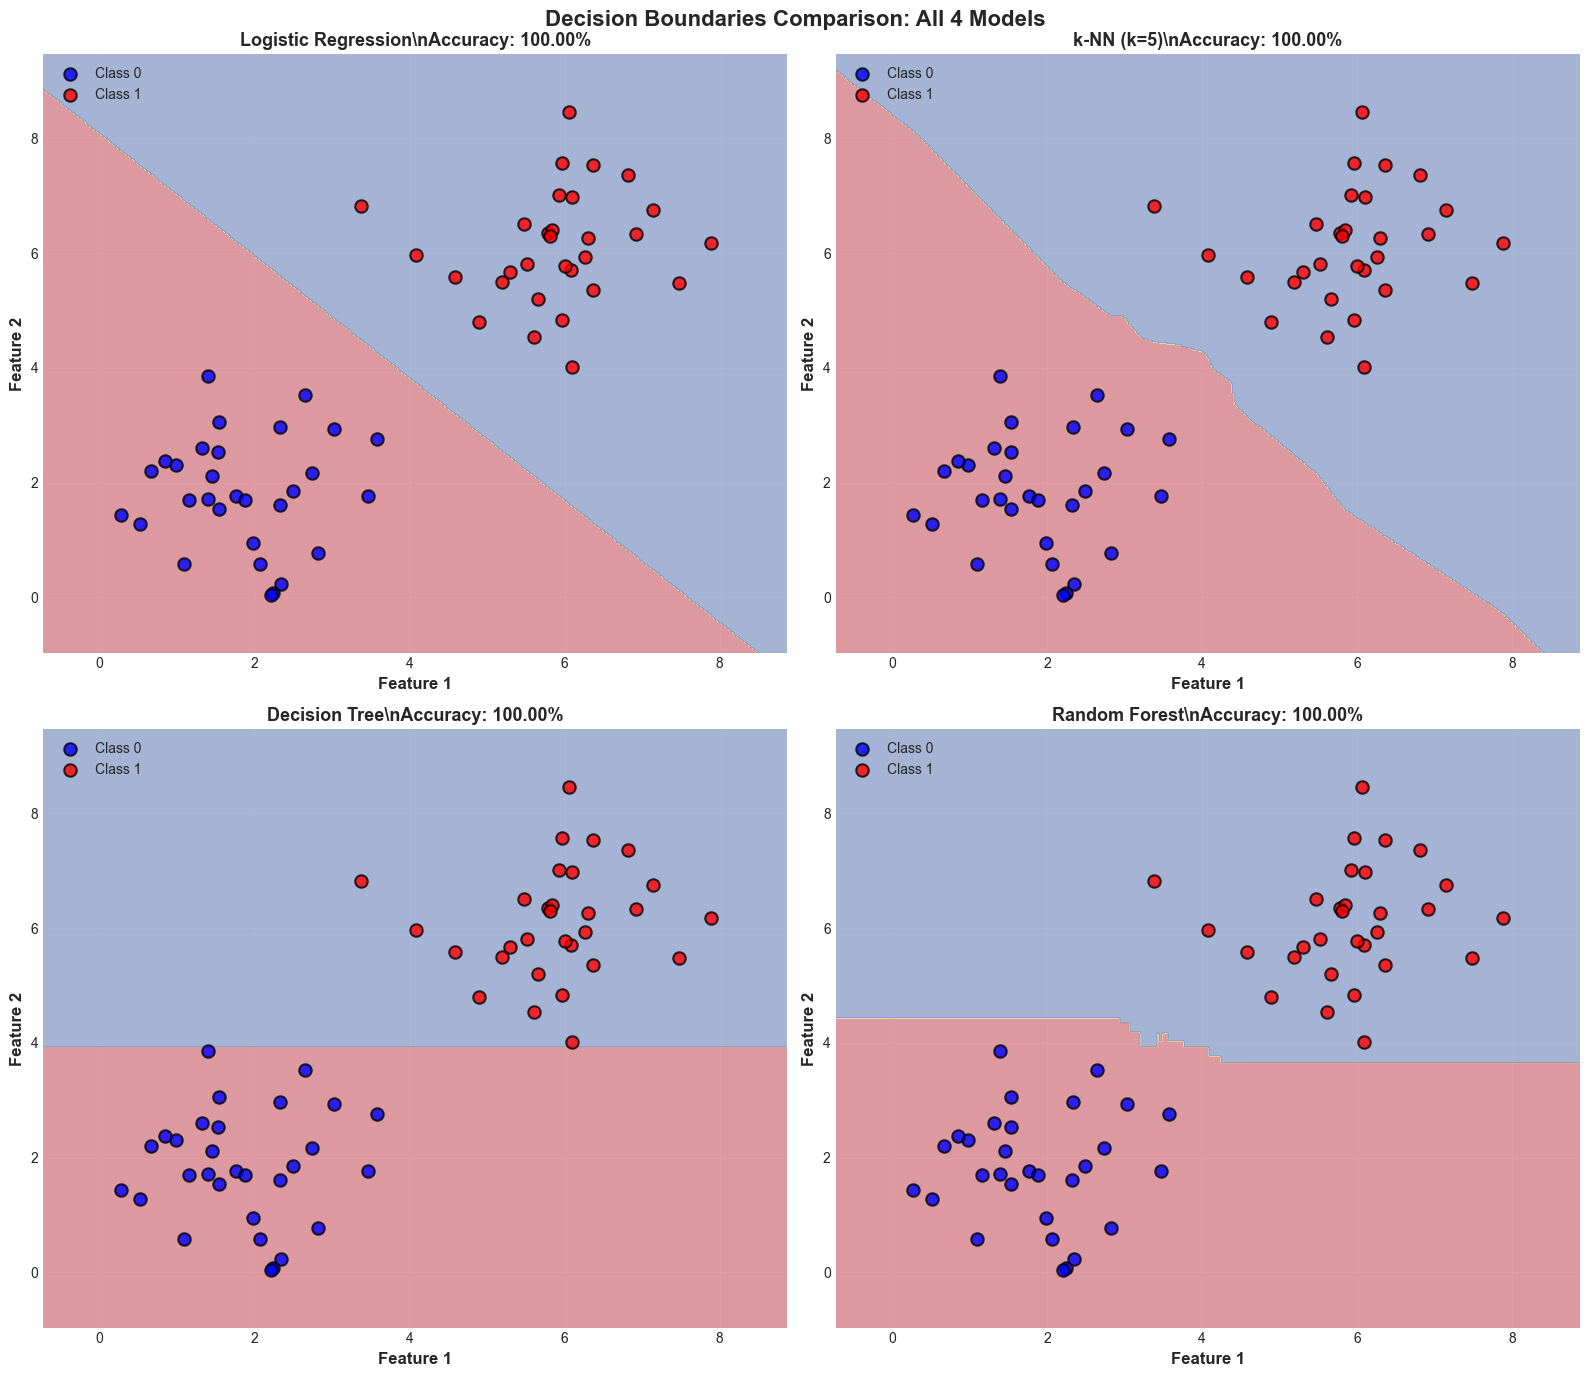

\n================================================================================
BARCHA MODELLAR: DECISION BOUNDARY TAQQOSLASH
\n📊 Logistic Regression:
  ✅ Linear (to'g'ri chiziq)
  ✅ Oddiy va tez
  ❌ Faqat linearly separable data uchun yaxshi
\n🎯 k-NN:
  ✅ Non-linear (murakkab shakl)
  ✅ Local patterns'ni yaxshi ushlab turadi
  ❌ Noise'ga sezgir (k kichik bo'lsa)
  ❌ Juda wiggly (to'lqinsimon)
\n🌳 Decision Tree:
  ✅ Non-linear (to'rtburchak region'lar)
  ✅ Interpretable
  ❌ Faqat vertikal/gorizontal split'lar
  ❌ Diagonal pattern'larda yomon
\n🌲 Random Forest:
  ✅ Non-linear va smooth
  ✅ Eng yaxshi accuracy
  ✅ Overfitting'ni kamaytiradi
  ✅ Barqaror va ishonchli
\n💡 Xulosa:
  - Oddiy dataset: Logistic Regression
  - Complex patterns: Random Forest
  - Interpretability kerak: Decision Tree
  - Small dataset: k-NN


In [ ]:
# Barcha modellar uchun decision boundary comparison
from sklearn.preprocessing import StandardScaler

# Data preparation
scaler_compare = StandardScaler()
X_knn_scaled = scaler_compare.fit_transform(X_knn)

# Models
models_compare = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

h = 0.02
x_min_comp, x_max_comp = X_knn[:, 0].min() - 1, X_knn[:, 0].max() + 1
y_min_comp, y_max_comp = X_knn[:, 1].min() - 1, X_knn[:, 1].max() + 1
xx_comp, yy_comp = np.meshgrid(np.arange(x_min_comp, x_max_comp, h),
                                np.arange(y_min_comp, y_max_comp, h))

for idx, (name, model) in enumerate(models_compare.items()):
    # Train model
    if name in ['Logistic Regression', 'k-NN (k=5)']:
        model.fit(X_knn_scaled, y_knn)
        # Scaled meshgrid
        xx_scaled = scaler_compare.transform(np.c_[xx_comp.ravel(), yy_comp.ravel()])
        Z_comp = model.predict(xx_scaled)
    else:
        model.fit(X_knn, y_knn)
        Z_comp = model.predict(np.c_[xx_comp.ravel(), yy_comp.ravel()])
    
    Z_comp = Z_comp.reshape(xx_comp.shape)
    
    # Plot
    axes[idx].contourf(xx_comp, yy_comp, Z_comp, alpha=0.4, cmap='RdYlBu')
    axes[idx].scatter(X_knn[y_knn==0, 0], X_knn[y_knn==0, 1], 
                      c='blue', s=80, alpha=0.8, edgecolors='black', linewidth=1.5, label='Class 0')
    axes[idx].scatter(X_knn[y_knn==1, 0], X_knn[y_knn==1, 1], 
                      c='red', s=80, alpha=0.8, edgecolors='black', linewidth=1.5, label='Class 1')
    
    # Accuracy
    if name in ['Logistic Regression', 'k-NN (k=5)']:
        accuracy_comp = model.score(X_knn_scaled, y_knn)
    else:
        accuracy_comp = model.score(X_knn, y_knn)
    
    axes[idx].set_xlabel('Feature 1', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Feature 2', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_comp:.2%}', fontsize=13, fontweight='bold')
    axes[idx].legend(fontsize=10, loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Decision Boundaries Comparison: All 4 Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BARCHA MODELLAR: DECISION BOUNDARY TAQQOSLASH")
print("="*80)

print("\n📊 Logistic Regression:")
print("  ✅ Linear (to'g'ri chiziq)")
print("  ✅ Oddiy va tez")
print("  ❌ Faqat linearly separable data uchun yaxshi")

print("\n🎯 k-NN:")
print("  ✅ Non-linear (murakkab shakl)")
print("  ✅ Local patterns'ni yaxshi ushlab turadi")
print("  ❌ Noise'ga sezgir (k kichik bo'lsa)")
print("  ❌ Juda wiggly (to'lqinsimon)")

print("\n🌳 Decision Tree:")
print("  ✅ Non-linear (to'rtburchak region'lar)")
print("  ✅ Interpretable")
print("  ❌ Faqat vertikal/gorizontal split'lar")
print("  ❌ Diagonal pattern'larda yomon")

print("\n🌲 Random Forest:")
print("  ✅ Non-linear va smooth")
print("  ✅ Eng yaxshi accuracy")
print("  ✅ Overfitting'ni kamaytiradi")
print("  ✅ Barqaror va ishonchli")

print("\n💡 Xulosa:")
print("  - Oddiy dataset: Logistic Regression")
print("  - Complex patterns: Random Forest")
print("  - Interpretability kerak: Decision Tree")
print("  - Small dataset: k-NN")
print("="*80)

In [56]:
# Barcha modellarni qayta train qilish (bir xil data bilan)
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # k-NN va Logistic uchun scaling kerak
    if name in ['Logistic Regression', 'k-NN (k=5)']:
        model.fit(X_train_i_scaled, y_train_i)
        y_pred = model.predict(X_test_i_scaled)
    else:
        model.fit(X_train_i, y_train_i)
        y_pred = model.predict(X_test_i)
    
    # Metrikalar
    results[name] = {
        'Accuracy': accuracy_score(y_test_i, y_pred),
        'Precision': precision_score(y_test_i, y_pred, average='weighted'),
        'Recall': recall_score(y_test_i, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test_i, y_pred, average='weighted')
    }

# Results DataFrame
results_df = pd.DataFrame(results).T
print("\n" + "="*70)
print("BARCHA MODELLAR TAQQOSLASH (Iris Dataset)")
print("="*70)
print(results_df)
print("="*70)


BARCHA MODELLAR TAQQOSLASH (Iris Dataset)
                     Accuracy  Precision    Recall  F1-Score
Logistic Regression  0.933333   0.933333  0.933333  0.933333
k-NN (k=5)           0.933333   0.944444  0.933333  0.932660
Decision Tree        0.966667   0.969697  0.966667  0.966583
Random Forest        0.900000   0.902357  0.900000  0.899749


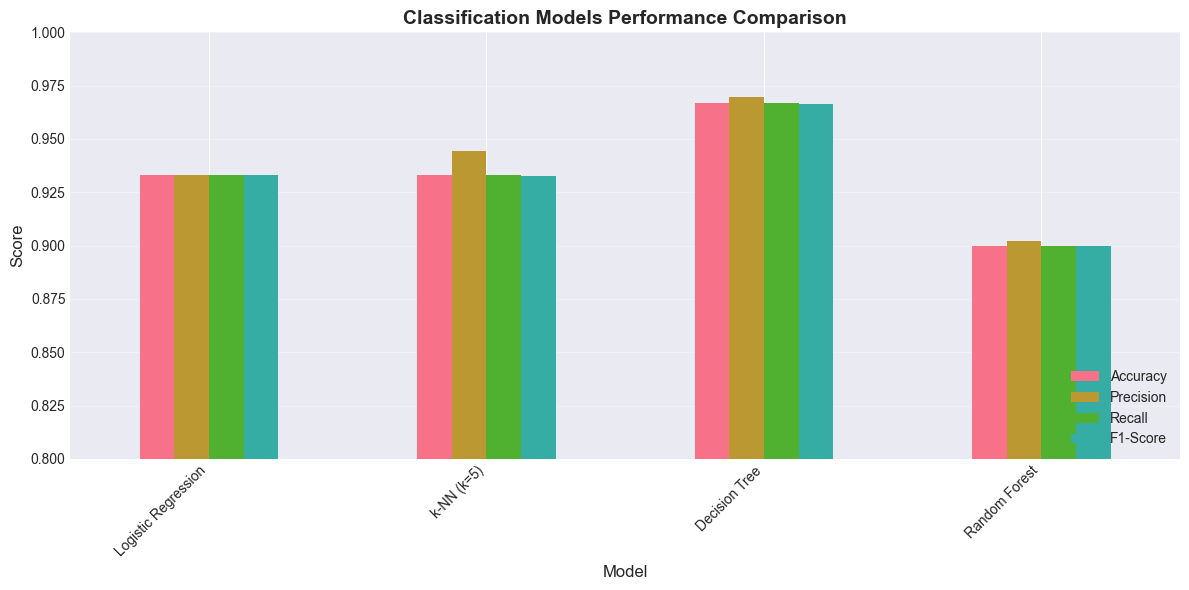

In [57]:
# Visualization: Model Comparison
results_df.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Classification Models Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right', fontsize=10)
plt.ylim(0.8, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

# 📝 Xulosa va Tavsiyalar

## 🎯 Qaysi modelni tanlash kerak?

### Logistic Regression
**Ishlatish:**
- ✅ Binary classification
- ✅ Interpretability muhim
- ✅ Tez natija kerak
- ✅ Linear decision boundary
- ✅ Probability kerak

**Ishlatmaslik:**
- ❌ Complex, non-linear relationships
- ❌ Juda ko'p feature'lar (regularization kerak)

### k-NN
**Ishlatish:**
- ✅ Oddiy dataset
- ✅ Multi-class classification
- ✅ Non-linear decision boundaries
- ✅ Training data doimiy o'zgaradi

**Ishlatmaslik:**
- ❌ Katta dataset (sekin)
- ❌ High-dimensional data
- ❌ Real-time prediction kerak

### Decision Tree
**Ishlatish:**
- ✅ Interpretability juda muhim
- ✅ Non-linear relationships
- ✅ Feature interactions
- ✅ Mixed data types
- ✅ No preprocessing needed

**Ishlatmaslik:**
- ❌ Overfitting muammosi
- ❌ Unstable (data o'zgarsa, tree juda o'zgaradi)

### Random Forest
**Ishlatish:**
- ✅ High accuracy kerak
- ✅ Overfitting oldini olish
- ✅ Feature importance kerak
- ✅ Complex patterns
- ✅ No preprocessing needed

**Ishlatmaslik:**
- ❌ Interpretability muhim
- ❌ Memory limited
- ❌ Real-time prediction (sekinroq)

## 💡 Best Practices

1. **Data Preprocessing:**
   - Scaling (k-NN, Logistic uchun)
   - Missing values handling
   - Categorical encoding

2. **Model Selection:**
   - Oddiydan boshlang (Logistic)
   - Complex modelga o'ting (Random Forest)
   - Cross-validation qiling

3. **Hyperparameter Tuning:**
   - GridSearchCV
   - RandomizedSearchCV

4. **Evaluation:**
   - Ko'p metrikalarni ishlating
   - Confusion matrix tahlil qiling
   - Class imbalance tekshiring

5. **Deployment:**
   - Eng yaxshi modelni saqlang
   - Test data'da yakuniy baholash

## 🚀 Keyingi Qadamlar

- Support Vector Machines (SVM)
- Naive Bayes
- Gradient Boosting (XGBoost, LightGBM)
- Neural Networks
- Deep Learning

---

**Endi `practical.ipynb` ga o'ting va amaliy mashqlarni bajaring! 🎯**